<center>
    <h1>DSM050 Data Visualisation</h1>
    <h3>Hadar Sharon</h3>
    <h3>2026-09-14</h3>
    <h2>Final coursework assignment</h2>
    <h3>University of London</h3>
    <h4>April 2026 session, MSc Data Science programme</h4>
</center>

---

## Introduction

### ___Camels in Transition___
#### _Mapping the changing scale, geography, and production intensity of global camel husbandry, 1961-2024_

Throughout history, camels have been important livestock in environments where water is scarce, heat is intense and foraging is challenging for most domestic species. Camels occupy a distinctive role in arid and semi-arid livestock systems - the Food and Agriculture Organization of the United Nations (FAO) describes them as multipurpose animals used for milk, meat, fibre, transport, and work. Their physiological tolerance of heat and water scarcity makes them especially important in dryland pastoral economies.

This project investigates how global camel husbandry has changed over more than six decades, using data from the __FAOSTAT Crops and Livestock Products (QCL)__ dataset.

One of the main issues encountered in this project is that global camel statistics are not all based on evidence of the same type or quality. National censuses, official submissions, FAO estimates and changes in political reporting entities can create apparent discontinuities that should not be interpreted naively (Faye, 2020). Data quality is therefore examined alongside the reported trends throughout the project.

## Research  topic

__How have the scale, geography and productive role of global camel husbandry changed since 1961, and how does data provenance affect the confidence we can place in that picture?__

### Research questions

* __RQ1:__ How has reported global camel stock changed between 1961 and 2024, and when did growth accelerate or slow?
* __RQ2:__ How has the regional distribution of camel stock changed, and which countries dominate the contemporary herd?
* __RQ3:__ How strongly is national camel herd size associated with recorded milk and meat production in 2024, and which countries deviate most from the broad relationship?
* __RQ4:__ How do leading camel-producing countries achieve milk and meat output through combinations of production scale (animals milked/slaughtered) and productivity (milk yield/carcass weight)?
* __RQ5:__ How much of reported camel stock is official versus estimated or imputed, and how should this qualify interpretation of recent country-level patterns?

## Data collection / Survey design

The data was downloaded directly from the __Food and Agriculture Organization of the United Nations (FAO), FAOSTAT Crops and Livestock Products domain (QCL)__. This notebook implements the complete workflow used in the accompanying report. It deliberately starts from the raw FAOSTAT data export so that the transformation from a wide annual format into a tidy analytical table is visible, controllable and reproducible. While a pre-normalised FAOSTAT export is available, it is not used as the primary input because that would remove a substantive data wrangling step.

FAOSTAT describes the main sources as official statistics supplied by member countries, originating from surveys, administrative data and expert estimates. Where official data are unavailable, unofficial sources, estimates or imputations may be used and are flagged accordingly.

FAOSTAT is particularly suitable for this analysis because it provides stock, milk and meat measures within the same statistical system, covering more than six decades and several geographic levels. This supports comparisons from World and continental aggregates down to contemporary countries without combining unrelated data sources. Its provenance flags are also analytically useful because they make it possible to investigate not only the reported values themselves but how those values were produced. However, using a common international dataset does not mean that measurement quality is consistent across countries or years.

From an __ethical and legal perspective__, the dataset contains aggregate agricultural statistics rather than personal or individual-level records, so privacy risk is minimal. FAOSTAT is released under CC BY 4.0. The main ethical concern is how the data are represented. Estimated livestock figures can appear more precise in a visualisation than the underlying evidence justifies. This motivates RQ5.

## Data overview and pre-processing

### Inspecting the non-normalised source (raw data)

The analysis uses three exact FAOSTAT items:

- `Camels` - live animal stocks (`An`, animals)
- `Raw milk of camel` - milk animals, production (`t`) and yield (`kg/An`)
- `Meat of camels, fresh or chilled` - animals slaughtered, production (`t`) and yield/carcass weight (`kg/An`)

The bulk data file also includes global, regional and special aggregates, as well as historical political entities. Global and regional results therefore use FAOSTAT's own aggregate rows. Contemporary country comparisons retain only M49 codes that map to present ISO-3166 entities using `pycountry`, while historical reporting entities are handled explicitly only where needed for long-run provenance checks.

We will start by reading the data files and inspecting the non-normalised source data.

In [1]:
from pathlib import Path

DATA_DIR = Path(r"data")

In [2]:
import pandas as pd

raw_df = pd.read_csv(DATA_DIR / "Production_Crops_Livestock_E_All_Data.csv.gz", low_memory=False)
area_codes_df = pd.read_csv(DATA_DIR / "Production_Crops_Livestock_E_AreaCodes.csv.gz")
item_codes_df = pd.read_csv(DATA_DIR / "Production_Crops_Livestock_E_ItemCodes.csv.gz")
flag_codes = pd.read_csv(DATA_DIR / "Production_Crops_Livestock_E_Flags.csv.gz")

In [3]:
dfs = {
    "Raw data": raw_df,
    "Area codes": area_codes_df,
    "Item codes": item_codes_df,
    "Flag codes": flag_codes,
}

with pd.option_context("display.show_dimensions", False):
    for name, df in dfs.items():
        print(f"\n{name} shape: {df.shape[0]:,} rows x {df.shape[1]:,} columns")
        display(df.head().style.hide(axis="index"))


Raw data shape: 78,974 rows x 201 columns


Area Code,Area Code (M49),Area,Item Code,Item Code (CPC),Item,Element Code,Element,Unit,Y1961,Y1961F,Y1961N,Y1962,Y1962F,Y1962N,Y1963,Y1963F,Y1963N,Y1964,Y1964F,Y1964N,Y1965,Y1965F,Y1965N,Y1966,Y1966F,Y1966N,Y1967,Y1967F,Y1967N,Y1968,Y1968F,Y1968N,Y1969,Y1969F,Y1969N,Y1970,Y1970F,Y1970N,Y1971,Y1971F,Y1971N,Y1972,Y1972F,Y1972N,Y1973,Y1973F,Y1973N,Y1974,Y1974F,Y1974N,Y1975,Y1975F,Y1975N,Y1976,Y1976F,Y1976N,Y1977,Y1977F,Y1977N,Y1978,Y1978F,Y1978N,Y1979,Y1979F,Y1979N,Y1980,Y1980F,Y1980N,Y1981,Y1981F,Y1981N,Y1982,Y1982F,Y1982N,Y1983,Y1983F,Y1983N,Y1984,Y1984F,Y1984N,Y1985,Y1985F,Y1985N,Y1986,Y1986F,Y1986N,Y1987,Y1987F,Y1987N,Y1988,Y1988F,Y1988N,Y1989,Y1989F,Y1989N,Y1990,Y1990F,Y1990N,Y1991,Y1991F,Y1991N,Y1992,Y1992F,Y1992N,Y1993,Y1993F,Y1993N,Y1994,Y1994F,Y1994N,Y1995,Y1995F,Y1995N,Y1996,Y1996F,Y1996N,Y1997,Y1997F,Y1997N,Y1998,Y1998F,Y1998N,Y1999,Y1999F,Y1999N,Y2000,Y2000F,Y2000N,Y2001,Y2001F,Y2001N,Y2002,Y2002F,Y2002N,Y2003,Y2003F,Y2003N,Y2004,Y2004F,Y2004N,Y2005,Y2005F,Y2005N,Y2006,Y2006F,Y2006N,Y2007,Y2007F,Y2007N,Y2008,Y2008F,Y2008N,Y2009,Y2009F,Y2009N,Y2010,Y2010F,Y2010N,Y2011,Y2011F,Y2011N,Y2012,Y2012F,Y2012N,Y2013,Y2013F,Y2013N,Y2014,Y2014F,Y2014N,Y2015,Y2015F,Y2015N,Y2016,Y2016F,Y2016N,Y2017,Y2017F,Y2017N,Y2018,Y2018F,Y2018N,Y2019,Y2019F,Y2019N,Y2020,Y2020F,Y2020N,Y2021,Y2021F,Y2021N,Y2022,Y2022F,Y2022N,Y2023,Y2023F,Y2023N,Y2024,Y2024F,Y2024N
2,'004,Afghanistan,221,'01371,"Almonds, in shell",5312,Area harvested,ha,0.000000,A,nan,0.000000,A,nan,0.000000,A,nan,0.000000,A,nan,0.000000,A,nan,0.000000,A,nan,0.000000,A,nan,0.000000,A,nan,0.000000,A,nan,0.000000,A,nan,0.000000,A,nan,0.000000,A,nan,0.000000,A,nan,0.000000,A,nan,0.000000,E,nan,5900.000000,E,nan,6000.000000,E,nan,6000.000000,E,nan,6000.000000,E,nan,5800.000000,E,nan,5800.000000,E,nan,5800.000000,E,nan,5700.000000,E,nan,5700.000000,E,nan,5600.000000,E,nan,5500.000000,E,nan,5500.000000,E,nan,5400.000000,E,nan,5400.000000,E,nan,6037.000000,E,nan,5500.000000,A,nan,5500.000000,A,nan,5500.000000,A,nan,5500.000000,A,nan,5500.000000,A,nan,5500.000000,A,nan,5500.000000,A,nan,5500.000000,A,nan,5500.000000,A,nan,7000.000000,E,nan,9000.000000,E,nan,5500.000000,A,nan,5700.000000,A,nan,12000.000000,X,Unofficial figure,11768.000000,I,nan,12000.000000,A,nan,12000.000000,A,nan,12000.000000,A,nan,11029.000000,A,nan,11210.000000,A,nan,13469.000000,A,nan,13490.000000,A,nan,14114.000000,A,nan,13703.000000,A,nan,14676.000000,A,nan,19481.000000,A,nan,19793.000000,A,nan,20053.000000,A,nan,29203.000000,A,nan,22134.000000,A,nan,36862.000000,A,nan,36462.000000,A,nan,37000.000000,A,nan,39794.000000,I,nan
2,'004,Afghanistan,221,'01371,"Almonds, in shell",5412,Yield,kg/ha,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,1661.000000,E,nan,1500.000000,E,nan,2000.000000,E,nan,1750.000000,E,nan,1706.900000,E,nan,1379.300000,E,nan,1896.600000,E,nan,1701.800000,E,nan,1842.100000,E,nan,1607.100000,E,nan,1818.200000,E,nan,1636.400000,E,nan,1666.700000,E,nan,1629.600000,E,nan,1573.600000,E,nan,1636.400000,A,nan,1800.000000,A,nan,1636.400000,A,nan,1636.400000,A,nan,1636.400000,A,nan,1636.400000,A,nan,1636.400000,A,nan,1636.400000,A,nan,2000.000000,E,nan,1714.300000,E,nan,1666.700000,E,nan,2140.700000,E,nan,2456.100000,E,nan,1225.000000,X,nan,1328.100000,E,nan,1666.700000,A,nan,2623.400000,A,nan,3500.000000,A,nan,3915.400000,E,nan,4995.500000,A,nan,4500.000000,A,nan,4596.000000,A,nan,2991.000000,A,nan,1999.600000,A,nan,1652.100000,A,nan,1685.900000,A,nan,1378.800000,A,nan,1716.100000,A,nan,1308.300000,A,nan,1775.900000,A,nan,1743.200000,A,nan,1742.000000,A,nan,1810.800000,A,nan,1741.900000,E,nan
2,'004,Afghanistan,221,'01371,"Almonds, in shell",5510,Production,t,0.000000,A,nan,0.000000,A,nan,0.000000,A,nan,0.000000,A,nan,0.000000,A,nan,0.000000,A,nan,0.000000,A,nan,0.000000,A,nan,0.000000,A,nan,0.000000,A,nan,0.000000,A,nan,0.000000,A,nan,0.000000,A,nan,0.000000,A,nan,0.000000,E


Area codes shape: 244 rows x 3 columns


Area Code,M49 Code,Area
2,'004,Afghanistan
5100,'002,Africa
3,'008,Albania
4,'012,Algeria
5200,'019,Americas



Item codes shape: 312 rows x 3 columns


Item Code,CPC Code,Item
809,'01929.07,Abaca; manila hemp; raw
800,'01929.06,Agave fibres; raw; n.e.c.
221,'01371,Almonds; in shell
711,'01654,Anise; badian; coriander; cumin; caraway; fennel and juniper berries; raw
515,'01341,Apples



Flag codes shape: 5 rows x 2 columns


Flag,Description
A,Official figure
E,Estimated value
I,Value imputed by a receiving agency
M,Missing value; data cannot exist
X,Figure from external organization


The source table is intentionally wide. Each logical series (country|item|element|unit) occupies one row, while each year is represented by three columns: a value (`Y1961`), a flag (`Y1961F`) and an optional note (`Y1961N`). This structure is convenient for distribution but not for analysis, so the central transformation is a wide-to-long reshape that keeps values, flags and notes aligned.

### Narrowing the analytical scope

In [4]:
# Check only camel-related items

display(item_codes_df[item_codes_df['Item'].str.contains('camel', case=False, na=False)].reset_index(drop=True))

,Item Code,CPC Code,Item
0,1126,'02121.01,Camels
1,1128,'21159.02,Edible offals of camels and other camelids; fr...
2,1129,'21519.02,Fat of camels
3,1127,'21117.01,Meat of camels; fresh or chilled
4,1158,'21117.02,Meat of other domestic camelids; fresh or chilled
5,1157,'02121.02,Other camelids
6,1130,'02293,Raw milk of camel


Only items required by the research questions are retained. Although offal, fat and "other camelids" appear in the camel-related search results, they are excluded because they would broaden the analysis beyond the central stock/milk/meat narrative. "Other camelids" data would additionally introduce non-camel species, such as llamas and alpacas.

In [5]:
CAMEL_ITEMS = [
    'Camels',
    'Raw milk of camel',
    'Meat of camels, fresh or chilled'
]

camel_wide = raw_df[raw_df['Item'].isin(CAMEL_ITEMS)]
print(f"Selected wide rows: {len(camel_wide):,}")

display(
    camel_wide.groupby(['Item', 'Element', 'Unit'])
              .size().rename('series')
              .reset_index()
)

Selected wide rows: 394


,Item,Element,Unit,series
0,Camels,Stocks,An,68
1,"Meat of camels, fresh or chilled",Producing Animals/Slaughtered,An,58
2,"Meat of camels, fresh or chilled",Production,t,58
3,"Meat of camels, fresh or chilled",Yield/Carcass Weight,kg/An,58
4,Raw milk of camel,Milk Animals,An,51
5,Raw milk of camel,Production,t,51
6,Raw milk of camel,Yield/Carcass Weight,kg/An,50


### Reshaping the value/flag/note triplets to tidy long form

This transformation is explicit rather than relying on the normalised data export available from FAOSTAT. A row in the resulting table represents a single `Area|Item|Element|Year` observation. Missing numeric values are intentionally not converted to zero: absence of a recorded figure is analytically different from a measured zero. `M` flags are retained because they communicate structural missingness.

In [6]:
# Get year columns present in wide dataframe
YEAR_COLS = camel_wide.filter(regex=r'^Y\d{4}$').columns

YEARS = YEAR_COLS.str[1:].astype(int).tolist()

ID_COLS = [
    'Area Code', 
    'Area Code (M49)', 
    'Area',
    'Item Code', 
    'Item Code (CPC)', 
    'Item',
    'Element Code', 
    'Element', 
    'Unit'
]

In [7]:
# wide-to-long transformation
camel_df = pd.concat(
    [
        camel_wide[ID_COLS].assign(
            Year=year,
            Value=pd.to_numeric(camel_wide[f'Y{year}'], errors='coerce'),
            Flag=camel_wide[f'Y{year}F'],
            Note=camel_wide[f'Y{year}N'],
        )
        for year in YEARS
    ],
    ignore_index=True,
)

camel_df = camel_df[camel_df['Value'].notna() | camel_df['Flag'].notna()]

print(f'Tidy rows retained (value or explicit flag present): {len(camel_df):,}')
display(camel_df.head())

Tidy rows retained (value or explicit flag present): 21,538


,Area Code,Area Code (M49),Area,Item Code,Item Code (CPC),Item,Element Code,Element,Unit,Year,Value,Flag,Note
0,2,'004,Afghanistan,1126,'02121.01,Camels,5111,Stocks,An,1961,250000.0,E,NaN
1,2,'004,Afghanistan,1127,'21117.01,"Meat of camels, fresh or chilled",5417,Yield/Carcass Weight,kg/An,1961,180.0,E,NaN
2,2,'004,Afghanistan,1127,'21117.01,"Meat of camels, fresh or chilled",5510,Production,t,1961,3600.0,I,NaN
3,2,'004,Afghanistan,1127,'21117.01,"Meat of camels, fresh or chilled",5320,Producing Animals/Slaughtered,An,1961,20000.0,E,NaN
4,2,'004,Afghanistan,1130,'02293,Raw milk of camel,5417,Yield/Carcass Weight,kg/An,1961,300.0,E,NaN


In [8]:
# M49 is stored with a leading apostrophe in the CSV. 
# convert it to a zero-padded numeric string and enrich with ISO3 code from PyCountry
import pycountry

def m49_to_iso3(code) -> str | None:
    return country.alpha_3 if (country := pycountry.countries.get(numeric=code)) else None


camel_df = camel_df.assign(
    M49=lambda df: df['Area Code (M49)'].astype(str).str.removeprefix("'").str.zfill(3),
    ISO3=lambda df: df['M49'].map(m49_to_iso3),
    is_current_country=lambda df: df['ISO3'].notna(),
)

print('Current ISO-mappable countries represented:', camel_df.loc[camel_df.is_current_country, 'Area'].nunique())
display(camel_df.head())

Current ISO-mappable countries represented: 46


,Area Code,Area Code (M49),Area,Item Code,Item Code (CPC),Item,Element Code,Element,Unit,Year,Value,Flag,Note,M49,ISO3,is_current_country
0,2,'004,Afghanistan,1126,'02121.01,Camels,5111,Stocks,An,1961,250000.0,E,NaN,004,AFG,True
1,2,'004,Afghanistan,1127,'21117.01,"Meat of camels, fresh or chilled",5417,Yield/Carcass Weight,kg/An,1961,180.0,E,NaN,004,AFG,True
2,2,'004,Afghanistan,1127,'21117.01,"Meat of camels, fresh or chilled",5510,Production,t,1961,3600.0,I,NaN,004,AFG,True
3,2,'004,Afghanistan,1127,'21117.01,"Meat of camels, fresh or chilled",5320,Producing Animals/Slaughtered,An,1961,20000.0,E,NaN,004,AFG,True
4,2,'004,Afghanistan,1130,'02293,Raw milk of camel,5417,Yield/Carcass Weight,kg/An,1961,300.0,E,NaN,004,AFG,True


### Separating aggregates and validating key units

`World`, continents and FAO development groupings do not map to ordinary ISO country codes and are kept separately. This avoids the common error of summing national observations together with regional/world aggregates.

A second issue is __political continuity__. FAOSTAT contains historical reporting entities such as `USSR`, `Ethiopia PDR` and `Sudan (former)`. Excluding them is appropriate for contemporary country comparisons but would make early national totals incomplete. For long-run provenance calculations these three entities are therefore retained alongside present-day ISO-mappable countries. Their series end when their successor reporting entities begin, so the combined reporting entity series reconciles to the FAOSTAT World aggregate without double counting. It also prevents historical and present-day political entities from being treated as directly continuous in country rankings. (Faye, 2020).

FAOSTAT uses `An` for animal counts, `t` for tonnes, and `kg/An` for yield/carcass weight. No cross-unit aggregation is performed.

In [9]:
import numpy as np

HISTORICAL_ENTITIES = ['Sudan (former)', 'Ethiopia PDR', 'USSR']

stocks = camel_df.query("Item == 'Camels' and Element == 'Stocks'")
country_stocks = stocks.query('is_current_country')
historical_stocks = stocks.query('Area in @HISTORICAL_ENTITIES')
reporting_entity_stocks = pd.concat(
    [country_stocks, historical_stocks],
    ignore_index=True,
)

world_stock = (
    stocks.query("Area == 'World'")
    .set_index('Year')['Value']
    .sort_index()
)

regions_stock = (
    stocks.query("Area in ['Africa', 'Asia', 'Europe']")
    .pivot(index='Year', columns='Area', values='Value')
    .sort_index()
)

# Current countries plus the three non-overlapping historical entities should
# reconcile to FAOSTAT's World total apart from trivial rounding.
reporting_stock = (
    reporting_entity_stocks.dropna(subset=['Value'])
    .groupby('Year')['Value'].sum()
    .reindex(world_stock.index)
)
reporting_coverage_pct = reporting_stock.div(world_stock).mul(100)
assert np.allclose(reporting_coverage_pct.dropna(), 100, atol=.01)

stocks_2024 = country_stocks.loc[
    country_stocks['Year'].eq(2024) & country_stocks['Value'].notna()
]

summary = pd.Series({
    'Raw FAOSTAT rows': len(raw_df),
    'Raw columns': raw_df.shape[1],
    'Camel-scope wide series': len(camel_wide),
    'Tidy camel observations/flags': len(camel_df),
    'Current countries with camel-stock series': country_stocks['Area'].nunique(),
    'Current countries with 2024 stock': stocks_2024['Area'].nunique(),
    'World stock 1961': world_stock.loc[1961],
    'World stock 2024': world_stock.loc[2024],
    'Reporting-entity coverage of 1961 World stock (%)': reporting_coverage_pct.loc[1961],
}, name='value').rename_axis('metric').reset_index()

display(summary.style.hide(axis='index').hide(axis='columns'))

Raw FAOSTAT rows,78974.000000
Raw columns,201.000000
Camel-scope wide series,394.000000
Tidy camel observations/flags,21538.000000
Current countries with camel-stock series,46.000000
Current countries with 2024 stock,46.000000
World stock 1961,12876790.000000
World stock 2024,44336084.000000
Reporting-entity coverage of 1961 World stock (%),100.000000


### Handling missingness and interpreting dataset flags

The FAOSTAT flags are analytically meaningful:

- __A__ - official figure
- __E__ - estimated value
- __I__ - value imputed by a receiving agency
- __X__ - figure from an external organisation
- __M__ - missing value, data cannot exist

A flag is not a standard error or confidence interval. The flags are used to group and contextualise observations, not as measures of statistical uncertainty.

In [10]:
stock_flag_counts = (
    stocks
    .groupby('Flag', dropna=False)
    .agg(
        records=('Year', 'size'),
        numeric_values=('Value', 'count'),
    )
    .sort_values('records', ascending=False)
)

coverage = (
    country_stocks.dropna(subset=['Value'])
    .groupby('Area')['Year']
    .agg(first_year='min', last_year='max', observed_years='nunique')
    .sort_values(['observed_years', 'Area'], ascending=[False, True])
)

display(stock_flag_counts)
display(coverage.head(15))

,records,numeric_values
Flag,,
A,2063,2063
E,1499,1499
I,158,158
X,71,71
M,29,0


,first_year,last_year,observed_years
Area,,,
Afghanistan,1961,2024,64
Algeria,1961,2024,64
Bahrain,1961,2024,64
Burkina Faso,1961,2024,64
Chad,1961,2024,64
"China, mainland",1961,2024,64
Djibouti,1961,2024,64
Egypt,1961,2024,64
India,1961,2024,64


## Analysis and results

The analysis is designed as a continuous visual narrative rather than as five independent answers to the research questions. It progresses from global scale to geographic redistribution, national trajectories, stock–output relationships, production mechanisms and finally, data provenance. Position and length are preferred where precise quantitative comparison matters, while colour, area and geographic position are used to reveal broader patterns, groupings, or spatial structure. Logarithmic scales are used only for variables spanning several orders of magnitude.

### RQ1 - How has the global camel population changed?

The World aggregate is used directly rather than recreated from country rows. This avoids distortions caused by changes in country coverage and political geography.

In [11]:
world = (
    world_stock
    .dropna()
    .rename('stock')
    .to_frame()
    .assign(
        annual_growth_pct=lambda df: df['stock'].pct_change().mul(100)
    )
)


def summarise_period(a, b):
    start, end = world.loc[[a, b], 'stock']

    return {
        'period': f'{a}–{b}',
        'start_m': start / 1e6,
        'end_m': end / 1e6,
        'CAGR_pct': ((end / start) ** (1 / (b - a)) - 1) * 100,
    }


periods = [
    (1961, 1980),
    (1980, 2000),
    (2000, 2010),
    (2010, 2020),
    (2020, 2024),
]

period_stats = pd.DataFrame(
    summarise_period(a, b) for a, b in periods
)

start, end = world.loc[[1961, 2024], 'stock']
long_run_cagr = ((end / start) ** (1 / (2024 - 1961)) - 1) * 100

display(period_stats.round(2))

print(
    f'1961: {start / 1e6:.2f} million | '
    f'2024: {end / 1e6:.2f} million | '
    f'multiple: {end / start:.2f}x | '
    f'long-run CAGR: {long_run_cagr:.2f}%'
)

,period,start_m,end_m,CAGR_pct
0,1961–1980,12.88,18.16,1.83
1,1980–2000,18.16,21.84,0.93
2,2000–2010,21.84,29.67,3.11
3,2010–2020,29.67,39.58,2.92
4,2020–2024,39.58,44.34,2.88


1961: 12.88 million | 2024: 44.34 million | multiple: 3.44x | long-run CAGR: 1.98%


findfont: Failed to find font weight medium, now using 400.


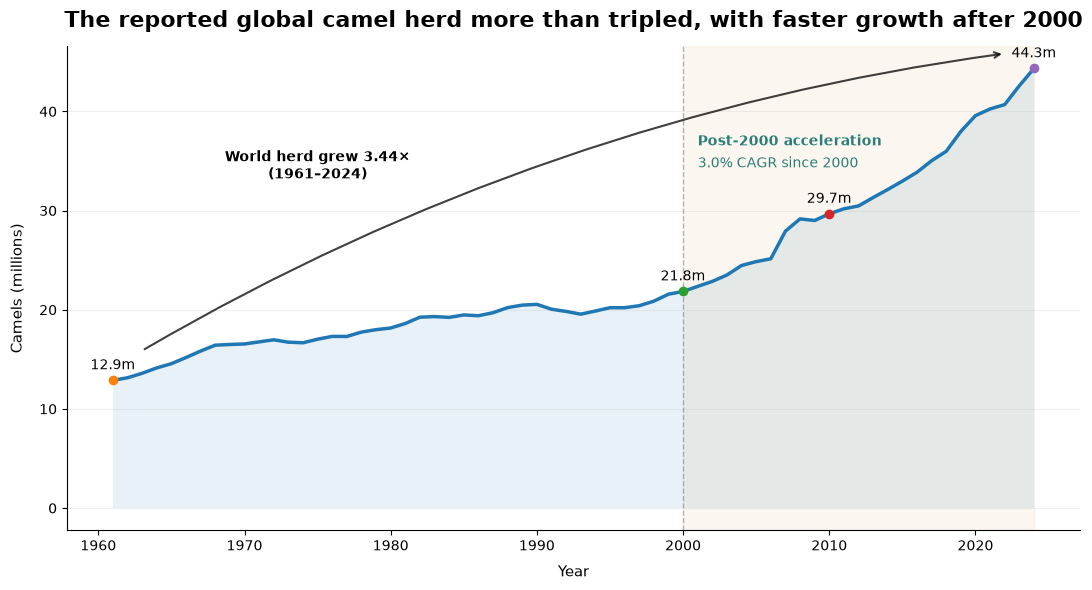

In [12]:
import matplotlib.pyplot as plt

plt.rcParams.update({
    'axes.spines.top': False,
    'axes.spines.right': False,
})

stock_m = world['stock'].div(1e6)
ymax = stock_m.max()

fig, ax = plt.subplots(figsize=(11, 6))

ax.plot(stock_m, linewidth=2.5)
ax.fill_between(stock_m.index, stock_m, alpha=0.10)

ax.set_title(
    'The reported global camel herd more than tripled, with faster growth after 2000',
    fontsize=16,
    fontweight='bold',
    pad=14,
)
ax.set_xlabel('Year', fontsize=11, fontweight='medium', labelpad=8)
ax.set_ylabel('Camels (millions)', fontsize=11, fontweight='medium', labelpad=10)
ax.grid(axis='y', alpha=0.2)

# Key years
for year in [1961, 2000, 2010, 2024]:
    value = stock_m.loc[year]
    ax.scatter(year, value, zorder=3)
    ax.annotate(
        f'{value:.1f}m',
        (year, value),
        xytext=(0, 8),
        textcoords='offset points',
        ha='center',
    )

# Post-2000 acceleration
start_2000, end_2024 = stock_m.loc[[2000, 2024]]
cagr_2000 = ((end_2024 / start_2000) ** (1 / 24) - 1) * 100

ax.axvspan(2000, 2024, color='#f2dec0', alpha=0.25, zorder=0)
ax.axvline(2000, color='#67767d', linestyle='--', linewidth=1, alpha=0.5)

ax.text(
    2001, ymax * 0.825,
    'Post-2000 acceleration',
    color='#2d7f78',
    fontweight='bold',
    fontsize=10,
)
ax.text(
    2001, ymax * 0.775,
    f'{cagr_2000:.1f}% CAGR since 2000',
    color='#2d7f78',
    fontsize=10,
)

# Long-run growth
start, end = stock_m.loc[[1961, 2024]]
multiple = end / start

ax.annotate(
    '',
    xy=(2022, end + 1.5),
    xytext=(1963, start + 3),
    arrowprops={
        'arrowstyle': '->',
        'linewidth': 1.5,
        'alpha': 0.75,
        'connectionstyle': 'arc3,rad=-0.10',
    },
)

ax.text(
    1975, ymax * 0.75,
    f'World herd grew {multiple:.2f}×\n(1961–2024)',
    ha='center',
    fontsize=10,
    fontweight='bold',
)

fig.tight_layout()
plt.show()

The reported world herd rises from about __12.9 million__ animals in 1961 to __44.3 million__ in 2024. Across the full 63-year period this corresponds to an annualised growth rate of approximately 2.0%, but the period averages conceal a pronounced change in pace - __the growth is not uniform__. The 1980-2000 period is comparatively slow, whereas the 2000s and 2010s each show annualised growth around 3%. The figures point to faster growth after 2000, although the world series remains a reported aggregate rather than a complete census of observed animals. (RQ5 will later determine whether recent totals depend heavily on imputation).

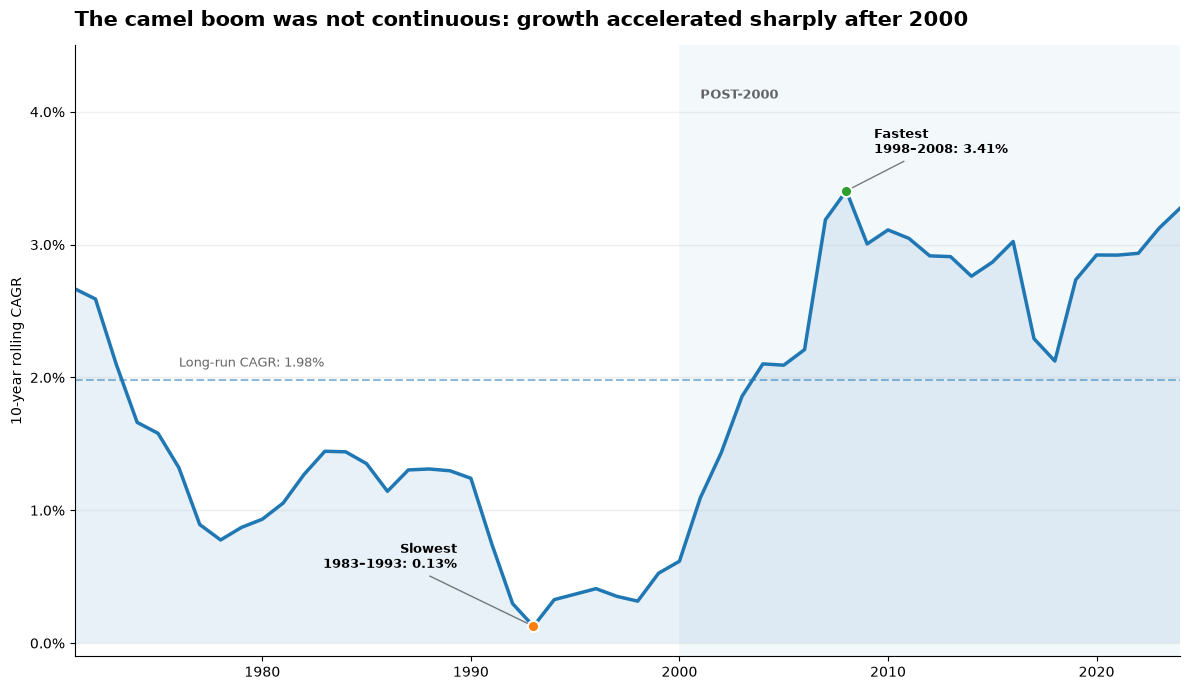

In [13]:
import matplotlib.ticker as mtick

window = 10

growth = (
    world['stock']
    .pct_change(window)
    .add(1)
    .pow(1 / window)
    .sub(1)
    .mul(100)
    .dropna()
)

fig, ax = plt.subplots(figsize=(12, 7))

# Main series and post-2000 period
ax.axvspan(2000, 2024, alpha=0.05, zorder=0)
ax.plot(growth, linewidth=2.5)
ax.fill_between(growth.index, 0, growth, alpha=0.1)

ax.text(
    2001, 4.1,
    'POST-2000',
    fontsize=9,
    fontweight='bold',
    alpha=0.6,
)

# Long-run benchmark
ax.axhline(long_run_cagr, linestyle='--', linewidth=1.5, alpha=0.5)
ax.text(
    growth.index.min() + 5,
    long_run_cagr + 0.1,
    f'Long-run CAGR: {long_run_cagr:.2f}%',
    fontsize=9,
    alpha=0.6,
)

# Fastest and slowest rolling decades
extremes = [
    ('Slowest', growth.idxmin(), (-55, 50), 'right'),
    ('Fastest', growth.idxmax(), (20, 35), 'left'),
]

for label, year, offset, ha in extremes:
    value = growth.loc[year]

    ax.scatter(
        year, value,
        s=65,
        edgecolor='white',
        linewidth=1.5,
        zorder=4,
    )

    ax.annotate(
        f'{label}\n{year-window}–{year}: {value:.2f}%',
        xy=(year, value),
        xytext=offset,
        textcoords='offset points',
        ha=ha,
        va='center',
        fontsize=9,
        fontweight='bold',
        arrowprops={
            'arrowstyle': '-',
            'linewidth': 1,
            'alpha': 0.5,
        },
    )

ax.set(
    xlabel='',
    ylabel=f'{window}-year rolling CAGR',
    xlim=(growth.index.min(), 2024),
    ylim=(-0.1, 4.5),
)

ax.set_title(
    'The camel boom was not continuous: growth accelerated sharply after 2000',
    loc='left',
    fontsize=15,
    fontweight='bold',
    pad=14,
)

ax.grid(axis='y', alpha=0.2, linewidth=1)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(100, decimals=1))

fig.tight_layout()
plt.show()

The long-run increase was not a steady process. The ten-year annualised growth rate __fell to almost to zero around the early 1990s__ before accelerating rapidly after 2000. The strongest rolling decade ended in 2008, recording approximately 3.4% growth per year. Rolling growth remains relatively high for several subsequent years, so the post-2000 rise cannot be attributed to a single anomalous year.

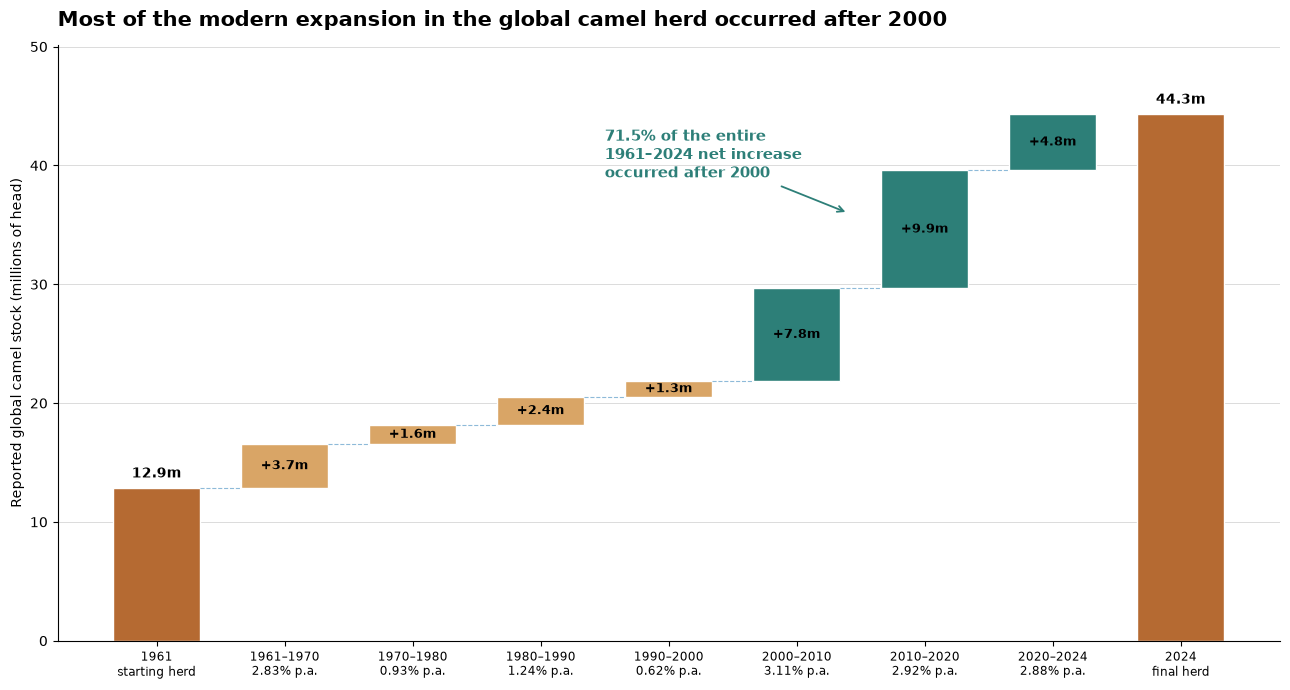

In [14]:
break_years = [1961, 1970, 1980, 1990, 2000, 2010, 2020, 2024]

stocks_m = world.loc[break_years, 'stock'].div(1e6)

periods = (
    pd.DataFrame({
        'start_year': break_years[:-1],
        'end_year': break_years[1:],
        'start_m': stocks_m.iloc[:-1].to_numpy(),
        'end_m': stocks_m.iloc[1:].to_numpy(),
    })
    .assign(
        change_m=lambda df: df['end_m'] - df['start_m'],
        cagr_pct=lambda df: (
            (df['end_m'] / df['start_m'])
            ** (1 / (df['end_year'] - df['start_year'])) - 1
        ) * 100,
    )
)

start_m, end_m = stocks_m.loc[[1961, 2024]]
x = np.arange(len(periods) + 2)
width = 0.68

fig, ax = plt.subplots(figsize=(13, 7))

# Start and final totals
totals = ax.bar(
    [x[0], x[-1]],
    [start_m, end_m],
    width=width,
    color='#b56a32',
    edgecolor='white',
)

ax.bar_label(
    totals,
    labels=[f'{start_m:.1f}m', f'{end_m:.1f}m'],
    padding=5,
    fontweight='bold',
)

# Period contributions
bars = ax.bar(
    x[1:-1],
    periods['change_m'],
    bottom=periods['start_m'],
    width=width,
    color=np.where(periods['start_year'] >= 2000, '#2d7f78', '#d9a566'),
    edgecolor='white',
)

for bar, change in zip(bars, periods['change_m']):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_y() + bar.get_height() / 2,
        f'{change:+.1f}m',
        ha='center',
        va='center',
        fontsize=9,
        fontweight='bold',
    )

# Waterfall connectors
ax.hlines(
    periods['start_m'],
    x[:-2] + width / 2,
    x[1:-1] - width / 2,
    linestyle='--',
    linewidth=0.8,
    alpha=0.5,
)

ax.set_xticks(
    x,
    [
        '1961\nstarting herd',
        *[
            f'{a}–{b}\n{c:.2f}% p.a.'
            for a, b, c in periods[
                ['start_year', 'end_year', 'cagr_pct']
            ].itertuples(index=False, name=None)
        ],
        '2024\nfinal herd',
    ],
    fontsize=8.5,
)

post_2000_share = (
    (stocks_m.loc[2024] - stocks_m.loc[2000])
    / (stocks_m.loc[2024] - stocks_m.loc[1961])
    * 100
)

ax.annotate(
    f'{post_2000_share:.1f}% of the entire\n'
    '1961–2024 net increase\n'
    'occurred after 2000',
    xy=(5.4, 36),
    xytext=(3.5, 39),
    fontsize=11,
    fontweight='bold',
    color='#2d7f78',
    arrowprops={
        'arrowstyle': '->',
        'color': '#2d7f78',
        'linewidth': 1.3,
    },
)

ax.set(
    xlabel='',
    ylabel='Reported global camel stock (millions of head)',
    ylim=(0, end_m * 1.13),
)

ax.set_title(
    'Most of the modern expansion in the global camel herd occurred after 2000',
    loc='left',
    fontsize=15,
    fontweight='bold',
    pad=14,
)

ax.grid(axis='y', alpha=0.45, linewidth=0.7)
ax.set_axisbelow(True)

fig.tight_layout()
plt.show()

Decomposing the change in absolute numbers makes the temporal shift especially clear. Only around 1.3 million additional camels were recorded between 1990 and 2000. By contrast, the reported herd increased by approximately 7.8 million during 2000–2010 and a further 9.9 million during 2010–2020. In total, roughly 71.5% of the entire net increase observed between 1961 and 2024 occurred after 2000. Most of the net increase in reported camel numbers has occurred during the 21st century.

### RQ2 - How has camel geography and concentration changed?

In [15]:
region_share = regions_stock.div(world_stock, axis='index').mul(100)

years = [1961, 1980, 2000, 2010, 2024]
display(region_share.loc[years].round(1))

Area,Africa,Asia,Europe
Year,,,
1961,66.6,31.2,2.2
1980,76.0,22.7,1.3
2000,82.8,17.1,0.0
2010,86.9,13.0,0.0
2024,83.5,16.5,0.0


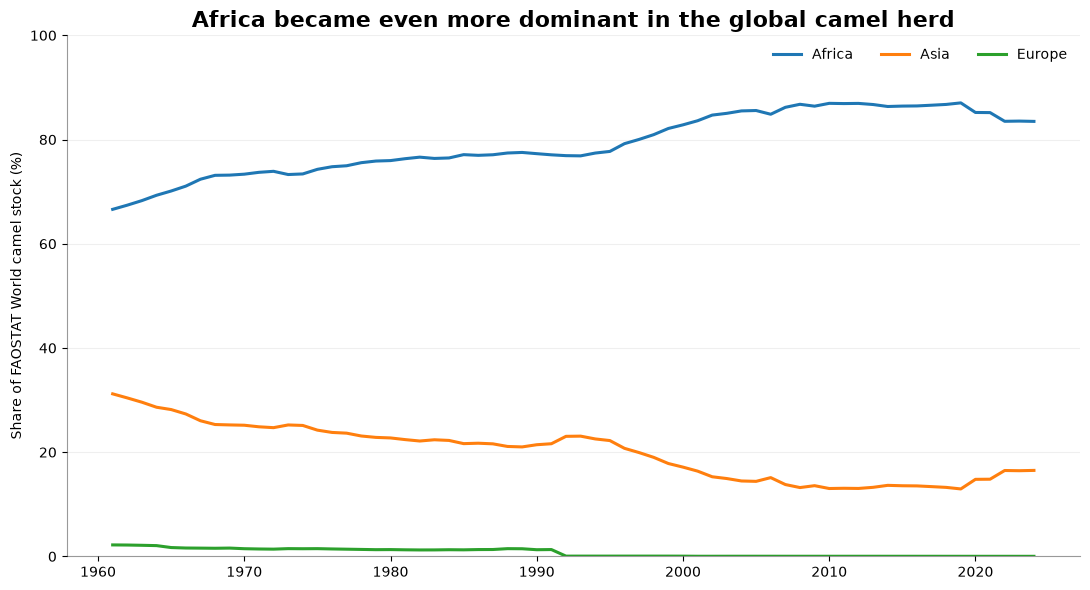

In [16]:
fig, ax = plt.subplots(figsize=(11, 6))

region_share[['Africa', 'Asia', 'Europe']].plot(
    ax=ax,
    linewidth=2.2,
)

ax.set(
    title='Africa became even more dominant in the global camel herd',
    xlabel='',
    ylabel='Share of FAOSTAT World camel stock (%)',
    ylim=(0, 100),
)

ax.title.set(fontsize=16, fontweight='bold')
ax.tick_params(labelsize=10)
ax.grid(axis='y', alpha=0.2)
ax.legend(ncol=3, frameon=False)

ax.spines[['top', 'right']].set_visible(False)
ax.spines[['left', 'bottom']].set(alpha=0.4, linewidth=0.8)

fig.tight_layout()
plt.show()

In [17]:
world_2024 = world_stock.loc[2024]

top = (
    country_stocks
    .query('Year == 2024')
    .dropna(subset=['Value'])
    .nlargest(15, 'Value')
    .assign(
        share_pct=lambda df: df['Value'].div(world_2024).mul(100)
    )
    [['Area', 'Value', 'share_pct']]
    .reset_index(drop=True)
)

top.index = top.index + 1
top.index.name = 'Rank'

display(
    top.style
    .format({
        'Value': '{:,.0f}',
        'share_pct': '{:.1f}%',
    })
    .relabel_index(
        ['Country', 'Camels', 'World share'],
        axis='columns',
    )
)

for n in [5, 10]:
    print(
        f'Top {n} countries: '
        f'{top.head(n)["share_pct"].sum():.1f}% of world stock'
    )

,Country,Camels,World share
Rank,,,
1,Chad,"11,379,091",25.7%
2,Somalia,"7,593,176",17.1%
3,Sudan,"4,839,720",10.9%
4,Kenya,"4,779,483",10.8%
5,Saudi Arabia,"2,436,191",5.5%
6,Niger,"1,957,356",4.4%
7,Ethiopia,"1,656,499",3.7%
8,Mauritania,"1,557,920",3.5%
9,Mali,"1,370,266",3.1%


Top 5 countries: 70.0% of world stock
Top 10 countries: 87.4% of world stock


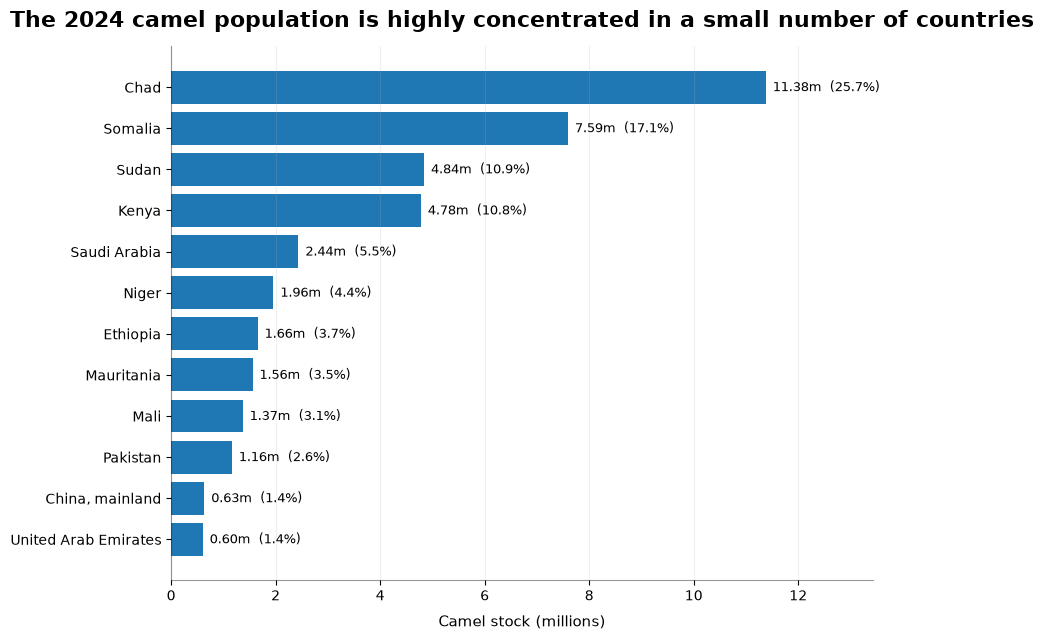

In [18]:
plot_top = (
    top
    .head(12)
    .sort_values('Value')
)

fig, ax = plt.subplots(figsize=(9, 6.5))

bars = ax.barh(
    plot_top['Area'],
    plot_top['Value'].div(1e6),
)

ax.bar_label(
    bars,
    labels=[
        f'{value / 1e6:.2f}m  ({share:.1f}%)'
        for value, share in zip(plot_top['Value'], plot_top['share_pct'])
    ],
    padding=5,
    fontsize=9,
)

ax.set_title(
    'The 2024 camel population is highly concentrated in a small number of countries',
    fontsize=16,
    fontweight='bold',
    pad=14,
)

ax.set_xlabel(
    'Camel stock (millions)',
    fontsize=11,
    fontweight='medium',
    labelpad=8,
)
ax.set_ylabel('')

ax.tick_params(axis='both', labelsize=10)
ax.grid(axis='x', alpha=0.2)
ax.margins(x=0.18)

for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)

for spine in ['left', 'bottom']:
    ax.spines[spine].set_alpha(0.4)
    ax.spines[spine].set_linewidth(0.8)

fig.tight_layout()
plt.show()

In [19]:
import geopandas as gpd

MAP_FILE = Path('data/naturalearth_lowres.shp')
if not MAP_FILE.exists():
    raise FileNotFoundError(f'Map layer not found: {MAP_FILE}')

world_change_2000_2024 = world_stock.loc[2024] - world_stock.loc[2000]

map_data = (
    country_stocks
    .query('Year in [2000, 2024]')
    .dropna(subset=['ISO3', 'Value'])
    .pivot(index=['ISO3', 'Area'], columns='Year', values='Value')
    .dropna()
    .assign(
        change=lambda df: df[2024] - df[2000],
        contribution=lambda df: df['change'].div(world_change_2000_2024).mul(100),
    )
    .reset_index()
)

comparable_growth_share = map_data['change'].sum() / world_change_2000_2024 * 100

geo_growth = (
    gpd.read_file(MAP_FILE)
    .merge(map_data, left_on='iso_a3', right_on='ISO3', how='left')
)

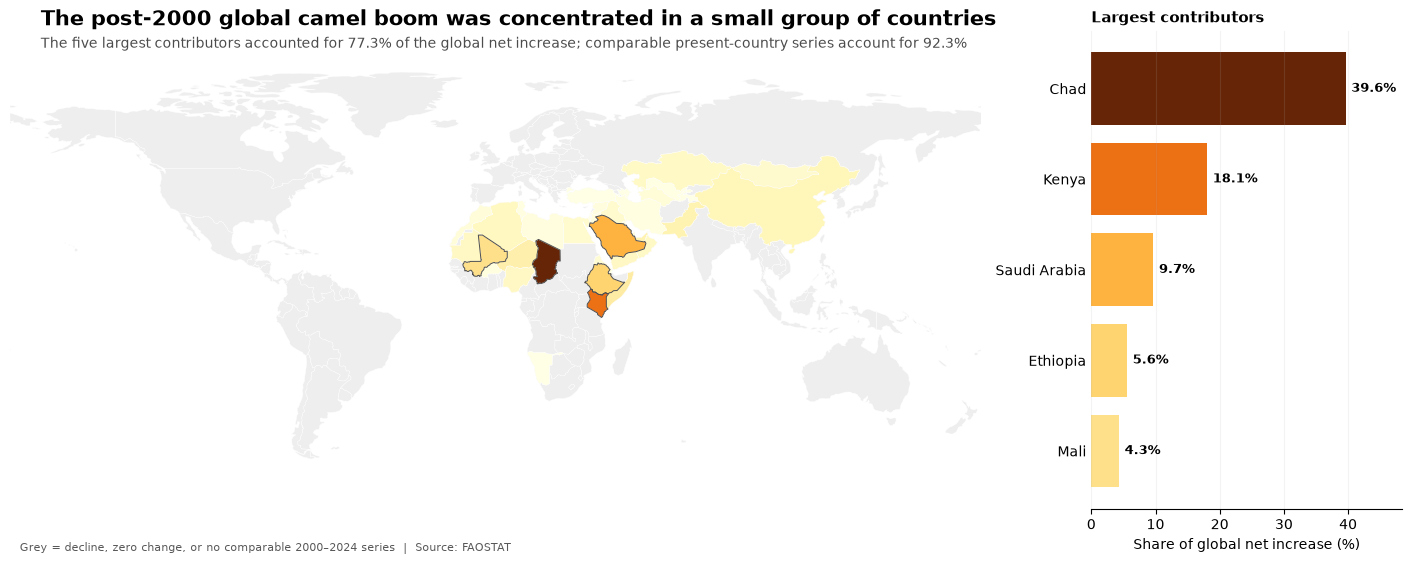

In [20]:
from matplotlib.colors import PowerNorm

leaders = (
    geo_growth
    .nlargest(5, 'contribution')
    .sort_values('contribution')
)

cmap = plt.colormaps['YlOrBr']
norm = PowerNorm(
    gamma=.6,
    vmin=0,
    vmax=geo_growth['contribution'].max(),
)

map_style = dict(edgecolor='white', linewidth=.3)

fig, (ax_map, ax_bar) = plt.subplots(
    1, 2,
    figsize=(14, 5.5),
    gridspec_kw={'width_ratios': [3.6, 1.15]},
    layout='constrained',
)

# Map
geo_growth.plot(ax=ax_map, color='#eeeeee', **map_style)

geo_growth.query('contribution > 0').plot(
    ax=ax_map,
    column='contribution',
    cmap=cmap,
    norm=norm,
    **map_style,
)

leaders.boundary.plot(ax=ax_map, color='.3', linewidth=.7)

ax_map.set(xlim=(-180, 180), ylim=(-60, 85))
ax_map.set_axis_off()

# Top contributors
bars = ax_bar.barh(
    leaders['Area'],
    leaders['contribution'],
    color=[cmap(norm(v)) for v in leaders['contribution']],
)

ax_bar.bar_label(
    bars,
    labels=leaders['contribution'].map('{:.1f}%'.format),
    padding=4,
    fontsize=9,
    fontweight='bold',
)

ax_bar.set(
    xlabel='Share of global net increase (%)',
    ylabel='',
    xlim=(0, leaders['contribution'].max() * 1.22),
)

ax_bar.set_title(
    'Largest contributors',
    loc='left',
    fontsize=11,
    fontweight='bold',
)

ax_bar.grid(axis='x', alpha=.15)
ax_bar.spines[['top', 'right', 'left']].set_visible(False)
ax_bar.tick_params(axis='y', length=0)

# Figure text
fig.suptitle(
    'The post-2000 global camel boom was concentrated in a small group of countries',
    fontsize=15,
    fontweight='bold',
    x=.025,
    y=.995,
    ha='left',
)

fig.text(
    .025,
    .925,
    f'The five largest contributors accounted for {leaders["contribution"].sum():.1f}% of the global net increase; '
    f'comparable present-country series account for {comparable_growth_share:.1f}%',
    fontsize=10,
    alpha=.7,
)

fig.text(
    .01, .01,
    'Grey = decline, zero change, or no comparable 2000–2024 series  |  Source: FAOSTAT',
    fontsize=8, alpha=.65,
)

plt.show()

In [21]:
panel = country_stocks.pivot(
    index='Area',
    columns='Year',
    values='Value',
)

change = (
    panel[[1961, 2024]]
    .dropna()
    .loc[lambda df: df.gt(0).all(axis=1)]
    .assign(
        absolute_change=lambda df: df[2024].sub(df[1961]),
        multiple=lambda df: df[2024].div(df[1961]),
    )
)

display(
    change
    .nlargest(12, 'absolute_change')
    .style.format({
        1961: '{:,.0f}',
        2024: '{:,.0f}',
        'absolute_change': '{:+,.0f}',
        'multiple': '{:.2f}x',
    })
)

print('\nLargest declines among present-day countries observed in both years:')

display(
    change
    .nsmallest(8, 'absolute_change')
    .style.format({
        1961: '{:,.0f}',
        2024: '{:,.0f}',
        'absolute_change': '{:+,.0f}',
        'multiple': '{:.2f}x',
    })
)

Year,1961,2024,absolute_change,multiple
Area,,,,
Chad,"300,000","11,379,091","+11,079,091",37.93x
Somalia,"2,900,000","7,593,176","+4,693,176",2.62x
Kenya,"350,000","4,779,483","+4,429,483",13.66x
Saudi Arabia,"80,000","2,436,191","+2,356,191",30.45x
Niger,"359,000","1,957,356","+1,598,356",5.45x
Mali,"159,000","1,370,266","+1,211,266",8.62x
Mauritania,"550,000","1,557,920","+1,007,920",2.83x
Pakistan,"600,898","1,163,000","+562,102",1.94x
United Arab Emirates,"100,000","604,855","+504,855",6.05x



Largest declines among present-day countries observed in both years:


Year,1961,2024,absolute_change,multiple
Area,,,,
India,"902,881","175,530","-727,351",0.19x
Mongolia,"859,100","480,567","-378,533",0.56x
Libya,"248,692","63,956","-184,736",0.26x
Morocco,"235,000","72,000","-163,000",0.31x
Iran (Islamic Republic of),"283,000","156,555","-126,445",0.55x
Afghanistan,"250,000","165,071","-84,929",0.66x
Iraq,"200,000","115,090","-84,910",0.58x
Türkiye,"65,390","1,137","-64,253",0.02x


A single national ranking covering 1961–2024 is not used because FAOSTAT's reporting geography changes over time (`USSR`, `Ethiopia PDR` and `Sudan (former)` as examples) - a long-run ranking would either exclude historically important reporting entities or compare changing states as if they were continuous. Long-run geographic change is instead shown using FAOSTAT's stable world/continental aggregates, while country trajectories below are restricted to present-day countries with observations at both endpoints (Faye, 2020).

Africa's share increases from roughly __66.6% in 1961__ to __83.5% in 2024__. The contemporary ranking shows a highly concentrated herd, while the 2000–2024 map locates most of the net increase in the Sahel, Horn of Africa and East Africa. Chad is the single largest contributor to post-2000 growth, with Kenya, Saudi Arabia, Ethiopia and Mali also prominent. Most of the increase is concentrated in the Sahel, Horn of Africa and East Africa, rather than being spread evenly across camel-keeping regions.

To exemplify how substantial the concentration is: Chad alone represents approximately 25.7% of reported World stock and Somalia a further 17.1%, meaning that __these two countries alone account for more than two-fifths of the global total__. The five largest national herds together account for 70.0%, rising to 87.4% for the top ten. The contemporary geography of camel husbandry is therefore not simply Africa-dominated, but concentrated within a relatively small number of national populations.

Africa's growing dominance notwithstanding, it was __not completely monotonic__. Its share reached approximately 86.9% in 2010 before easing to 83.5% in 2024 as Asia regained a small proportion of the global total.

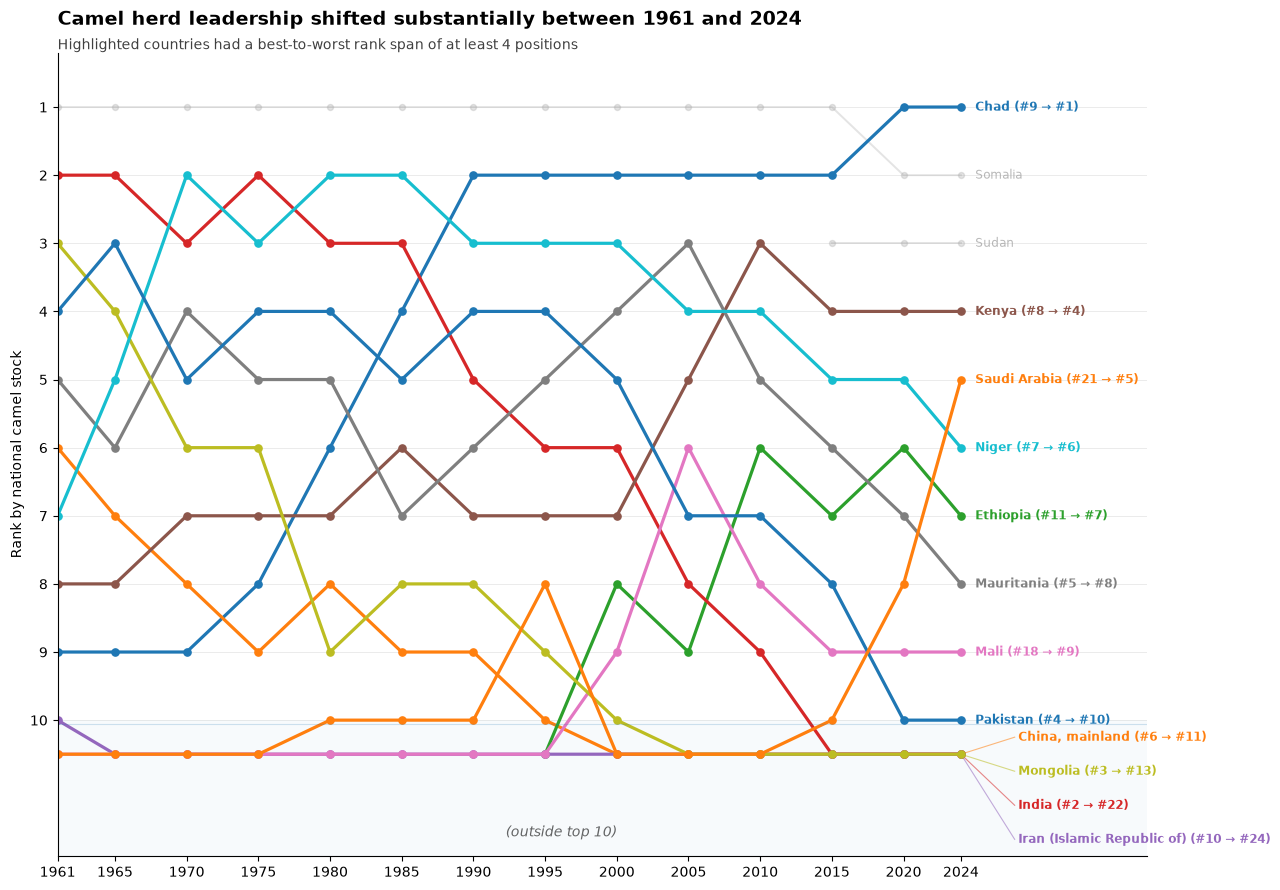

In [22]:
bump_years = [1961, *range(1965, 2024, 5), 2024]
top_n = 10
min_rank_shift = 4

ranks = (
    country_stocks
    .query('Year in @bump_years')
    .dropna(subset=['Value'])
    [['Area', 'Year', 'Value']]
    .sort_values(['Year', 'Value'], ascending=[True, False])
    .assign(Rank=lambda df: df.groupby('Year').cumcount() + 1)
)

# Countries appearing in the top 10 at either endpoint.
end_set = set(
    ranks.query('Year in [1961, 2024] and Rank <= @top_n')['Area']
)

bump = (
    ranks[ranks['Area'].isin(end_set)]
    .assign(PlotRank=lambda df: df['Rank'].clip(upper=top_n + 0.5))
)

# Highlight countries whose best-to-worst rank span is meaningful.
movement = (
    bump
    .sort_values('Year')
    .groupby('Area')['Rank']
    .agg(best='min', worst='max', start='first', end='last')
    .assign(span=lambda df: df['worst'] - df['best'])
)

highlight = set(movement.query('span >= @min_rank_shift').index)

colors = {
    area: plt.cm.tab10.colors[i % 10]
    for i, area in enumerate(sorted(highlight))
}

# Stagger labels for countries ending outside the visible top 10.
last = (
    bump
    .sort_values('Year')
    .groupby('Area')
    .tail(1)
    .set_index('Area')
)

outside = last.query('Rank > @top_n').sort_values('Rank')

outside_y = dict(zip(
    outside.index,
    np.linspace(top_n + 0.25, top_n + 1.75, len(outside)),
))

fig, ax = plt.subplots(figsize=(13, 9))

for area, data in bump.groupby('Area'):
    data = data.sort_values('Year')
    final = data.iloc[-1]

    highlighted = area in highlight
    outside_top = final['Rank'] > top_n
    color = colors.get(area, '0.65')

    ax.plot(
        data['Year'],
        data['PlotRank'],
        marker='o',
        markersize=5.2 if highlighted else 4.3,
        linewidth=2.3 if highlighted else 1.4,
        color=color,
        alpha=1 if highlighted else 0.3,
        zorder=2 if highlighted else 1,
    )

    label_x = 2028 if outside_top else 2025
    label_y = outside_y.get(area, final['PlotRank'])

    if outside_top:
        ax.plot(
            [2024, label_x - 0.25],
            [final['PlotRank'], label_y],
            color=color,
            linewidth=0.8,
            alpha=0.55 if highlighted else 0.25,
            clip_on=False,
        )

    if highlighted:
        start, end = movement.loc[area, ['start', 'end']].astype(int)
        label = f'{area} (#{start} → #{end})'
    elif outside_top:
        label = f'{area} (#{int(final["Rank"])})'
    else:
        label = area

    ax.text(
        label_x,
        label_y,
        label,
        va='center',
        fontsize=8.6,
        color=color,
        fontweight='bold' if highlighted else 'normal',
        alpha=1 if highlighted else 0.8,
    )

# Overflow band for ranks below 10.
ax.axhspan(top_n, top_n + 2, alpha=0.03)
ax.axhline(top_n + 0.05, linewidth=0.8, alpha=0.2)

ax.text(
    2000,
    top_n + 1.65,
    f'(outside top {top_n})',
    ha='right',
    va='center',
    fontsize=10,
    fontstyle='italic',
    alpha=0.6,
)

ax.set(
    xlim=(1961, 2037),
    ylim=(top_n + 2, 0.2),
    xticks=bump_years,
    yticks=range(1, top_n + 1),
    xlabel='',
    ylabel='Rank by national camel stock',
)

ax.set_title(
    'Camel herd leadership shifted substantially between 1961 and 2024',
    loc='left',
    fontsize=14,
    fontweight='bold',
    pad=20,
)

ax.text(
    0,
    1,
    f'Highlighted countries had a best-to-worst rank span of at least '
    f'{min_rank_shift} positions',
    transform=ax.transAxes,
    fontsize=10,
    alpha=0.75,
    va='bottom',
)

ax.grid(axis='y', alpha=0.25, linewidth=0.7)

fig.tight_layout()
plt.show()

In [23]:
START_YEAR, END_YEAR, TOP_N = 1961, 2024, 20

top_countries = (
    country_stocks
    .query('Year == @END_YEAR')
    .nlargest(TOP_N, 'Value')['Area']
)

trajectory = (
    country_stocks
    .query('Area in @top_countries and @START_YEAR <= Year <= @END_YEAR')
    .pivot(index='Area', columns='Year', values='Value')
    .dropna(subset=[START_YEAR, END_YEAR])
    .loc[lambda df: df[START_YEAR] > 0]
)

relative = (
    np.log2(trajectory.div(trajectory[START_YEAR], axis=0))
    .sort_values(END_YEAR, ascending=False)
)

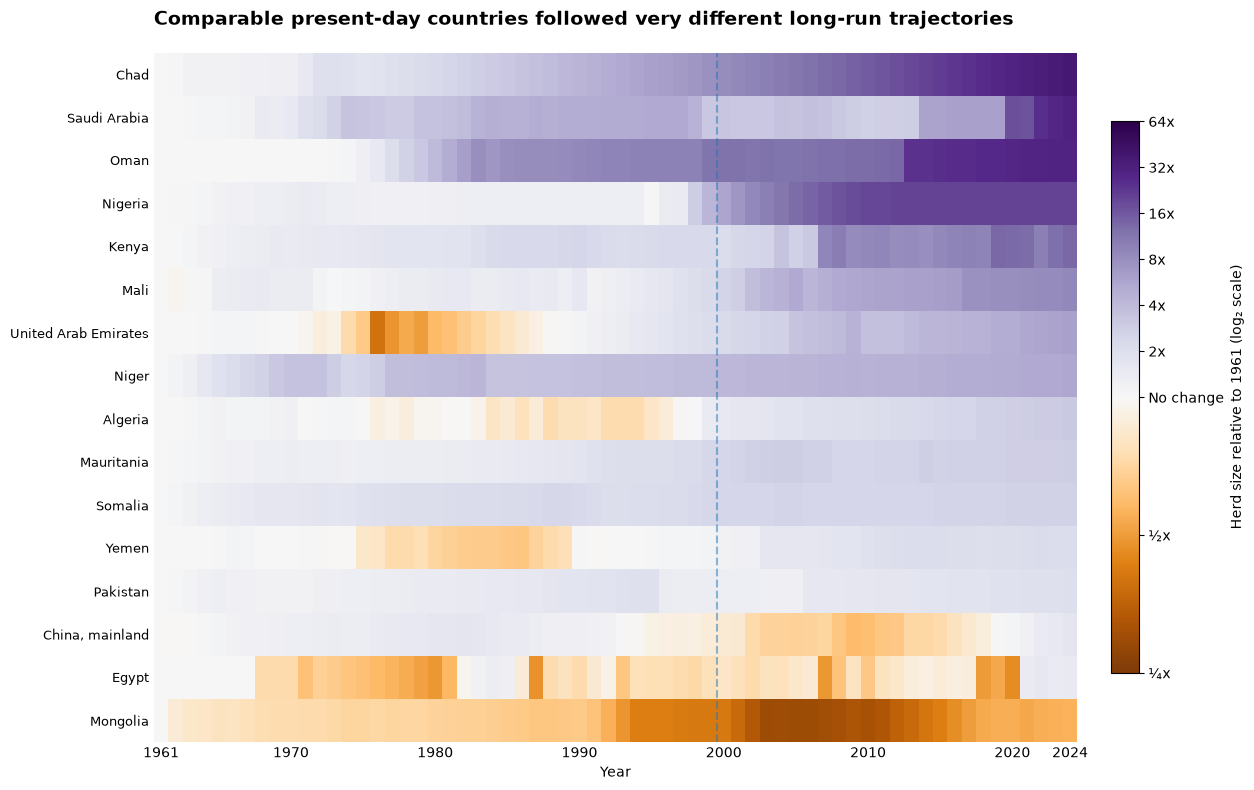

In [24]:
from matplotlib.colors import TwoSlopeNorm


fig, ax = plt.subplots(figsize=(13, 8))

norm = TwoSlopeNorm(vmin=-2, vcenter=0, vmax=6)
im = ax.imshow(relative, aspect='auto', cmap='PuOr', norm=norm)

tick_years = [1961, 1970, 1980, 1990, 2000, 2010, 2020, 2024]
ax.set_xticks(relative.columns.get_indexer(tick_years), tick_years)
ax.set_yticks(range(len(relative)), relative.index, fontsize=9)

ax.axvline(relative.columns.get_loc(2000) - .5, linestyle='--', alpha=.5)

ax.set(
    xlabel='Year',
    ylabel='',
)
ax.set_title(
    'Comparable present-day countries followed very different long-run trajectories',
    loc='left',
    fontsize=14,
    fontweight='bold',
    pad=20,
)
ax.tick_params(length=0)
ax.set_frame_on(False)

cbar = fig.colorbar(im, ax=ax, shrink=.8, pad=.03)
cbar.set_ticks(
    range(-2, 7),
    labels=['¼x', '½x', 'No change', '2x', '4x', '8x', '16x', '32x', '64x'],
)
cbar.set_label('Herd size relative to 1961 (log₂ scale)')

fig.tight_layout()
plt.show()

Among present-day countries with observations at both endpoints, the indexed heatmap shows that the camel boom was far from uniform. Chad, Saudi Arabia, Oman and Nigeria recorded very strong long-run expansion, but the timing differed substantially. Nigeria and Kenya, for example, accelerated mainly after 2000, whereas Saudi Arabia and Oman experienced substantial earlier growth. At the opposite extreme, Mongolia's 2024 herd remained below its 1961 level. These trajectories complement the aggregate regional story without treating historical political entities as if national boundaries had remained fixed since 1961.

### RQ3 - How strongly is herd size associated with recorded milk and meat output?

A country with more camels has a larger potential production base, but total herd size is not in itself a production measure. Milk depends on how many animals are actually milked and their yield, likewise meat depends on slaughter numbers and carcass weight. 

RQ3 therefore asks how strongly __total national camel stock__ is associated with recorded annual output, and which countries depart most from that broad relationship. FAOSTAT's reference periods are not perfectly aligned: livestock numbers are grouped into 12-month periods ending 30 September, while milk and meat generally refer to calendar years. The 2024 data provides an approximate cross-section, since stock and production measures do not use exactly the same reference periods. Meat data also refer to animals slaughtered within national boundaries irrespective of origin, which can further weaken a simple herd-to-output relationship.

In [25]:
YEAR = 2024

stock24 = (
    country_stocks
    .query('Year == @YEAR and Value > 0')
    [['Area', 'ISO3', 'Value', 'Flag']]
    .rename(columns={'Value': 'Herd', 'Flag': 'HerdFlag'})
)

def herd_output(item):
    production = (
        camel_df
        .query(
            'Item == @item and Element == "Production" '
            'and is_current_country and Year == @YEAR and Value > 0'
        )
        [['Area', 'ISO3', 'Value', 'Flag']]
        .rename(columns={'Value': 'Production', 'Flag': 'ProductionFlag'})
    )

    return (
        stock24
        .merge(production, on=['Area', 'ISO3'])
        .assign(
            Intensity=lambda d: d.Production / d.Herd * 1_000,
            Herd_m=lambda d: d.Herd / 1e6,
            Production_kt=lambda d: d.Production / 1e3
        )
    )

milk_relation = herd_output('Raw milk of camel')
meat_relation = herd_output('Meat of camels, fresh or chilled')

print(f'Matched countries - milk: {len(milk_relation)}, meat: {len(meat_relation)}')

Matched countries - milk: 29, meat: 37


In [26]:
def fit_herd_model(df):
    x = np.log10(df['Herd'])
    y = np.log10(df['Production'])
    slope, intercept = np.polyfit(x, y, 1)
    fitted_log = intercept + slope * x
    r2 = 1 - ((y - fitted_log) ** 2).sum() / ((y - y.mean()) ** 2).sum()

    return (
        df.assign(
            Fitted=10 ** fitted_log,
            Actual_vs_fitted=lambda d: d['Production'] / d['Fitted'],
        ),
        slope,
        r2,
    )


milk_model, milk_slope, milk_r2 = fit_herd_model(milk_relation)
meat_model, meat_slope, meat_r2 = fit_herd_model(meat_relation)

Because herd sizes and production quantities span several orders of magnitude, both are plotted on logarithmic scales. The fitted line is descriptive and is not intended as a causal production model. Countries are compared with the output fitted from herd size alone; $R^2$ is reported on the log-transformed scale.

In [27]:
def plot_herd_prediction(df, product, color, labels, slope, r2):
    fig, ax = plt.subplots(figsize=(11.5, 6.5))

    ax.scatter(
        df['Herd_m'], df['Production_kt'],
        s=75, color=color, alpha=.8,
        edgecolor='white', linewidth=.8, zorder=3,
    )

    fit = df.sort_values('Herd')
    x = fit['Herd_m']
    y = fit['Fitted'] / 1e3

    ax.plot(
        x, y,
        color='#243238', linewidth=2, linestyle='--',
        label=f'Expected from herd size alone (slope {slope:.2f}, $R^2$ {r2:.2f})',
    )

    ax.fill_between(
        x, y / 2, y * 2,
        color=color, alpha=.08,
        label='Within 0.5×–2× of expectation',
    )

    by_area = df.set_index('Area')
    for area, offset in labels.items():
        if area not in by_area.index:
            continue

        r = by_area.loc[area]
        ax.annotate(
            area,
            (r['Herd_m'], r['Production_kt']),
            xytext=offset,
            textcoords='offset points',
            fontsize=8.5,
            fontweight='bold',
            arrowprops={'arrowstyle': '-', 'lw': .7, 'alpha': .6},
        )

    ax.set(
        xscale='log',
        yscale='log',
        xlabel='Total camel herd (million head, log scale)',
        ylabel=f'Recorded {product.lower()} production (thousand tonnes, log scale)',
    )

    ax.set_title(
        f'Herd size predicts the broad pattern of {product.lower()} production — '
        'but important countries depart from it',
        loc='left',
        fontweight='bold',
    )

    ax.legend(frameon=False, loc='upper left')
    ax.grid(which='major', alpha=.45, linewidth=.7)
    ax.grid(which='minor', alpha=.12, linewidth=.5)

    fig.tight_layout()
    plt.show()

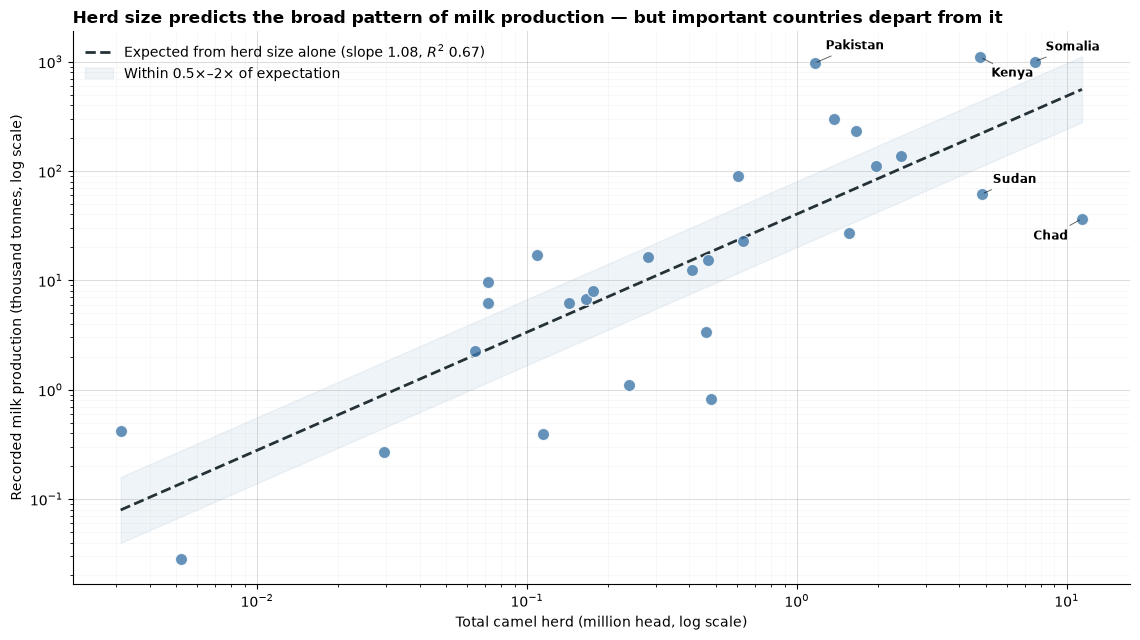

In [28]:
milk_labels = {
    'Chad': (-35, -15),
    'Pakistan': (8, 10),
    'Somalia': (8, 8),
    'Kenya': (8, -14),
    'Sudan': (8, 8),
}

plot_herd_prediction(
    milk_model,
    'Milk',
    '#3f77a8',
    milk_labels,
    milk_slope,
    milk_r2,
)

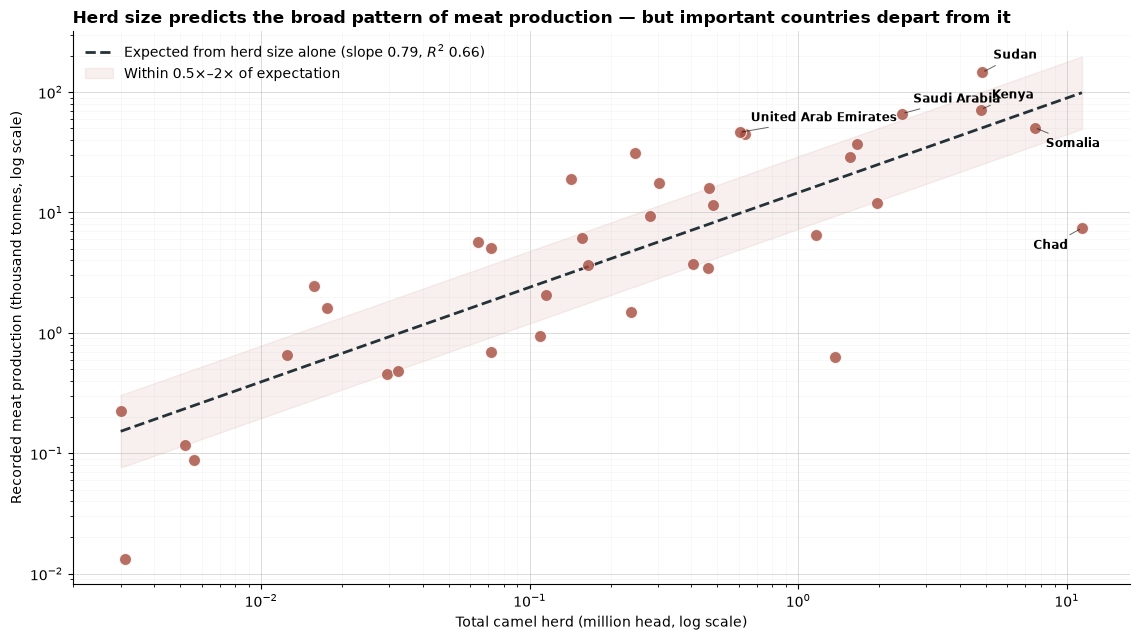

In [29]:
meat_labels = {
    'Chad': (-35, -15),
    'Sudan': (8, 10),
    'Somalia': (8, -14),
    'Kenya': (8, 8),
    'Saudi Arabia': (8, 8),
    'United Arab Emirates': (8, 8),
}

plot_herd_prediction(
    meat_model,
    'Meat',
    '#a64b3c',
    meat_labels,
    meat_slope,
    meat_r2,
)

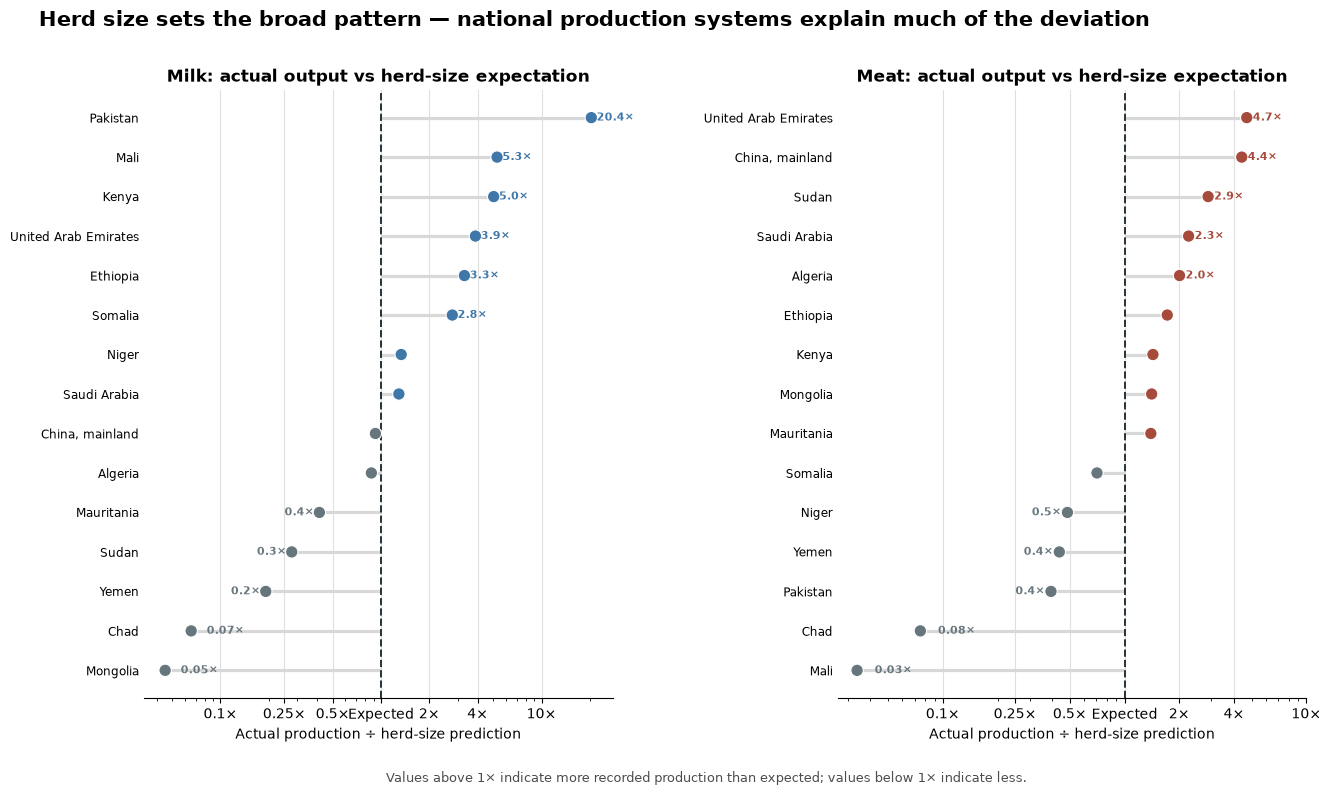

In [30]:
def expectation_panel(ax, df, product, color, n=15):
    d = (
        df.nlargest(n, 'Herd')
        .sort_values('Actual_vs_fitted')
    )

    y = np.arange(len(d))
    ratio = d['Actual_vs_fitted']

    ax.hlines(y, 1, ratio, color='#d8d8d8', linewidth=2.3)

    ax.scatter(
        ratio, y,
        s=80,
        c=np.where(ratio >= 1, color, '#67767d'),
        edgecolor='white',
        linewidth=.8,
        zorder=3,
    )

    ax.axvline(1, color='#243238', linestyle='--', linewidth=1.4)

    ax.set_xscale('log')
    ax.set_yticks(y, d['Area'], fontsize=8.5)
    ax.set_xticks(
        [.1, .25, .5, 1, 2, 4, 10],
        ['0.1×', '0.25×', '0.5×', 'Expected', '2×', '4×', '10×'],
    )

    for yi, value in zip(y, ratio):
        if value >= 2 or value <= .5:
            very_low = value < .1
            ax.text(
                value * (1.25 if very_low else 1.08 if value >= 1 else .92),
                yi,
                f'{value:.2f}×' if very_low else f'{value:.1f}×',
                ha='left' if value >= 1 or very_low else 'right',
                va='center',
                fontsize=8,
                fontweight='bold',
                color=color if value >= 1 else '#67767d',
            )

    ax.set(
        xlabel='Actual production ÷ herd-size prediction',
        title=f'{product}: actual output vs herd-size expectation',
    )
    ax.title.set(fontsize=12, fontweight='bold')
    ax.tick_params(axis='y', length=0)
    ax.grid(axis='x', alpha=.4)
    ax.spines['left'].set_visible(False)


fig, axes = plt.subplots(1, 2, figsize=(15, 8))

expectation_panel(axes[0], milk_model, 'Milk', '#3f77a8')
expectation_panel(axes[1], meat_model, 'Meat', '#a64b3c')

fig.suptitle(
    'Herd size sets the broad pattern — national production systems explain much of the deviation',
    x=.055,
    ha='left',
    fontsize=15,
    fontweight='bold',
)

fig.text(
    .5, .015,
    'Values above 1× indicate more recorded production than expected; '
    'values below 1× indicate less.',
    ha='center',
    fontsize=9,
    alpha=.7,
)

fig.subplots_adjust(top=.88, bottom=.12, wspace=.48)
plt.show()

On the log-transformed scale, the bivariate herd-size model accounts for approximately 67% of the variation in log recorded milk output ($R^2 \approx 0.67$) and 66% for meat ($R^2 \approx 0.66$). Herd size is clearly related to production, but it leaves roughly one-third of the variation unexplained. The remaining variation may reflect production intensity, herd utilisation or reporting differences, although the model cannot separate these effects.

Pakistan is the clearest milk-side deviation, while several large-herd countries record considerably less output than the herd-only fit would suggest. RQ4 examines whether these differences come from the number of animals used for production, recorded productivity, or both.

In [31]:
def production_profile(milk, meat, n=15):
    p = (
        milk[['Area', 'ISO3', 'Herd', 'Intensity']]
        .rename(columns={'Intensity': 'Milk'})
        .merge(
            meat[['Area', 'ISO3', 'Intensity']]
            .rename(columns={'Intensity': 'Meat'}),
            on=['Area', 'ISO3'],
        )
        .nlargest(n, 'Herd')
        .assign(Herd_m=lambda d: d['Herd'].div(1e6))
    )

    milk_med, meat_med = p[['Milk', 'Meat']].median()

    return p.assign(
        Profile=np.select(
            [
                p['Milk'].ge(milk_med) & p['Meat'].lt(meat_med),
                p['Milk'].lt(milk_med) & p['Meat'].ge(meat_med),
                p['Milk'].ge(milk_med) & p['Meat'].ge(meat_med),
            ],
            ['Milk-oriented', 'Meat-oriented', 'High on both'],
            default='Low on both',
        ),
        Balance=np.log10(p['Milk'].div(p['Meat'])),
        Overall=np.sqrt(p['Milk'].mul(p['Meat'])),
    )


profile = production_profile(milk_relation, meat_relation)

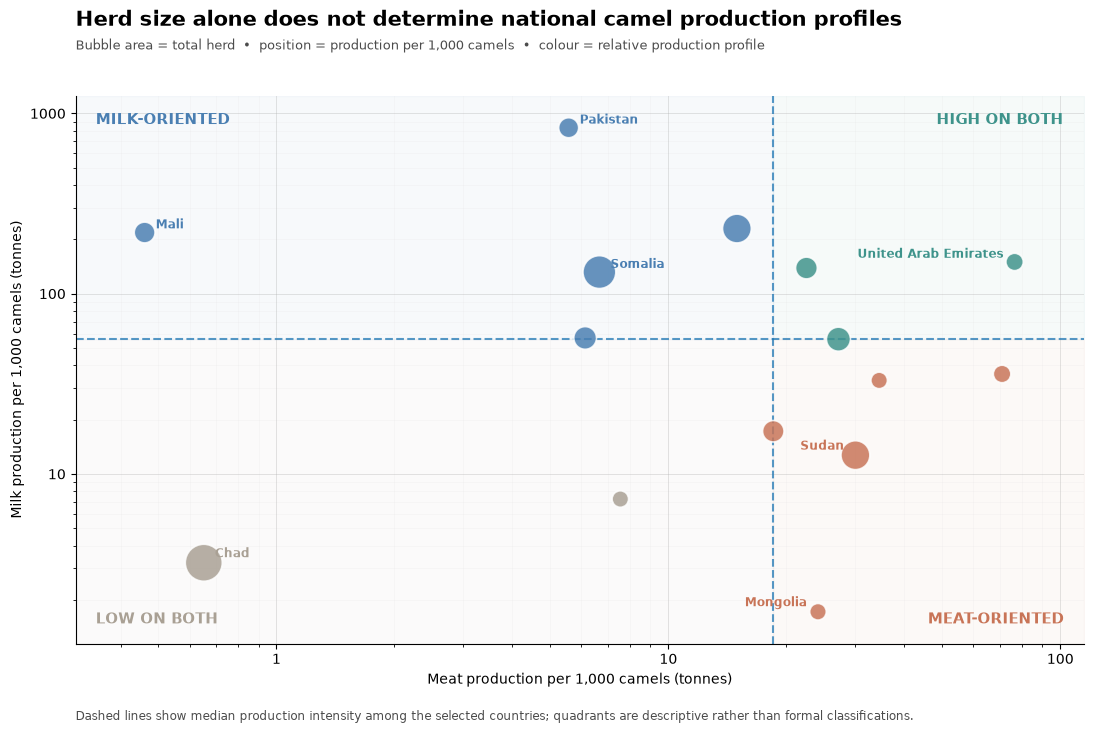

In [32]:
PROFILE_COLORS = {
    'Milk-oriented': '#4a7fb2',
    'Meat-oriented': '#c87457',
    'High on both': '#3e938b',
    'Low on both': '#a9a094',
}


def plot_production_profile(p):
    mx, my = p[['Meat', 'Milk']].median()
    xmin, xmax = p['Meat'].min() / 1.5, p['Meat'].max() * 1.5
    ymin, ymax = p['Milk'].min() / 1.5, p['Milk'].max() * 1.5

    p = p.assign(
        Size=60 + 650 * (p['Herd_m'] / p['Herd_m'].max()) ** .65
    )

    fig, ax = plt.subplots(figsize=(12, 7.5))
    fig.subplots_adjust(top=.86, bottom=.13, left=.11, right=.95)

    ax.set(
        xscale='log',
        yscale='log',
        xlim=(xmin, xmax),
        ylim=(ymin, ymax),
        xlabel='Meat production per 1,000 camels (tonnes)',
        ylabel='Milk production per 1,000 camels (tonnes)',
    )

    zones = [
        (xmin, mx, my, ymax, 'Milk-oriented'),
        (mx, xmax, my, ymax, 'High on both'),
        (xmin, mx, ymin, my, 'Low on both'),
        (mx, xmax, ymin, my, 'Meat-oriented'),
    ]
    for x0, x1, y0, y1, group in zones:
        ax.fill_between(
            [x0, x1], y0, y1,
            color=PROFILE_COLORS[group], alpha=.045,
        )

    ax.axvline(mx, linestyle='--', alpha=.75)
    ax.axhline(my, linestyle='--', alpha=.75)

    for group, d in p.groupby('Profile'):
        ax.scatter(
            d['Meat'], d['Milk'],
            s=d['Size'],
            color=PROFILE_COLORS[group],
            alpha=.84,
            edgecolor='white',
            linewidth=1.2,
            zorder=3,
        )

    labelled = (
        pd.concat([
            p.nlargest(3, 'Herd'),
            p.nlargest(2, 'Balance'),
            p.nsmallest(2, 'Balance'),
            p.nlargest(2, 'Overall'),
        ])
        .drop_duplicates('Area')
    )

    for r in labelled.itertuples():
        left = r.Meat <= mx
        ax.annotate(
            r.Area,
            (r.Meat, r.Milk),
            xytext=(8 if left else -8, 4 if r.Milk <= my else 3),
            textcoords='offset points',
            ha='left' if left else 'right',
            fontsize=8.6,
            fontweight='bold',
            color=PROFILE_COLORS[r.Profile],
        )

    quadrants = [
        (.02, .97, 'MILK-ORIENTED', 'Milk-oriented', 'left', 'top'),
        (.98, .97, 'HIGH ON BOTH', 'High on both', 'right', 'top'),
        (.02, .03, 'LOW ON BOTH', 'Low on both', 'left', 'bottom'),
        (.98, .03, 'MEAT-ORIENTED', 'Meat-oriented', 'right', 'bottom'),
    ]
    for x, y, text, group, ha, va in quadrants:
        ax.text(
            x, y, text,
            transform=ax.transAxes,
            ha=ha, va=va,
            fontsize=11,
            fontweight='bold',
            color=PROFILE_COLORS[group],
        )

    fig.suptitle(
        'Herd size alone does not determine national camel production profiles',
        x=.11, y=.975, ha='left',
        fontsize=15, fontweight='bold',
    )
    fig.text(
        .11, .922,
        'Bubble area = total herd  •  position = production per 1,000 camels  •  '
        'colour = relative production profile',
        fontsize=9.5, alpha=.7,
    )

    fmt = mtick.FuncFormatter(lambda x, _: f'{x:g}')
    ax.xaxis.set_major_formatter(fmt)
    ax.yaxis.set_major_formatter(fmt)

    ax.grid(which='major', alpha=.35, linewidth=.7)
    ax.grid(which='minor', alpha=.08, linewidth=.5)
    ax.spines[['top', 'right']].set_visible(False)

    fig.text(
        .11, .028,
        'Dashed lines show median production intensity among the selected countries; '
        'quadrants are descriptive rather than formal classifications.',
        fontsize=8.5, alpha=.7,
    )

    plt.show()


plot_production_profile(profile)

This comparison shows that national camel herds are not associated with uniform recorded production intensity. In other words - recorded production intensity differs substantially between countries: Pakistan, Mali and Somalia sit in the chart's milk-oriented quadrant, while Sudan and Mongolia show much stronger meat intensity relative to milk. Chad, despite having the largest herd in the plot, lies near the low end of both measures, whereas the United Arab Emirates combines a comparatively modest herd with high recorded intensity for both products. The quadrants are descriptive only and are not intended as formal classifications of national production systems.

### RQ4 - How is output produced through scale and productivity?

FAOSTAT's production elements allow a useful decomposition of recorded output:

- __Milk production__ reflects the number of milk animals together with recorded milk yield.
- __Meat production__ reflects the number of animals slaughtered together with recorded carcass weight.

Separating the components makes it possible to distinguish output driven mainly by the number of animals from output associated with higher recorded yield or carcass weight.

In [33]:
def product_snapshot(item, required, year=2024):
    d = (
        camel_df
        .query('Item == @item and is_current_country and Year == @year')
        .dropna(subset=['Value'])
    )

    key = ['Area', 'ISO3', 'Element']
    assert not d.duplicated(key).any(), f'Unexpected duplicate elements for {item}, {year}'

    return (
        d.pivot(index=['Area', 'ISO3'], columns='Element', values='Value')
        .dropna(subset=required)
        .reset_index()
    )

In [34]:
milk24 = product_snapshot(
    'Raw milk of camel',
    ['Milk Animals', 'Production', 'Yield/Carcass Weight'],
)

meat24 = product_snapshot(
    'Meat of camels, fresh or chilled',
    ['Producing Animals/Slaughtered', 'Production', 'Yield/Carcass Weight'],
)


def show_top(df, columns):
    display(
        df.nlargest(12, 'Production')
        .style.format({c: '{:,.0f}' for c in columns})
    )


show_top(milk24, ['Milk Animals', 'Production', 'Yield/Carcass Weight'])
show_top(meat24, ['Producing Animals/Slaughtered', 'Production', 'Yield/Carcass Weight'])

Element,Area,ISO3,Milk Animals,Production,Yield/Carcass Weight
11,Kenya,KEN,"1,679,624","1,098,082",654
23,Somalia,SOM,"2,509,152","999,967",399
18,Pakistan,PAK,"431,000","968,000","2,246"
13,Mali,MLI,"452,161","299,181",662
7,Ethiopia,ETH,"277,281","229,858",829
21,Saudi Arabia,SAU,"278,528","136,204",489
17,Niger,NER,"248,312","111,170",448
27,United Arab Emirates,ARE,"353,139","90,684",257
24,Sudan,SDN,"1,692,098","61,493",36
3,Chad,TCD,"297,247","36,598",123


Element,Area,ISO3,Producing Animals/Slaughtered,Production,Yield/Carcass Weight
30,Sudan,SDN,"540,226","145,228",269
15,Kenya,KEN,"238,974","71,490",299
27,Saudi Arabia,SAU,"500,657","66,164",132
29,Somalia,SOM,"293,250","50,626",173
34,United Arab Emirates,ARE,"256,907","46,241",180
5,"China, mainland",CHN,"179,340","45,033",251
9,Ethiopia,ETH,"179,961","37,277",207
7,Egypt,EGY,"123,667","31,035",251
19,Mauritania,MRT,"141,441","28,856",204
33,Turkmenistan,TKM,"66,909","18,840",282


Pakistan illustrates the distinction particularly clearly. It records approximately 968,000 tonnes of camel milk from about 431,000 milk animals, almost matching Somalia's 1.00 million tonnes despite Somalia reporting approximately 2.51 million milk animals. The difference corresponds to a recorded yield of about 2,246 kg per milk animal in Pakistan, compared with 399 kg in Somalia and 654 kg in Kenya.

These differences cannot be attributed to biological productivity alone. Production systems, statistical definitions and estimation practices may also contribute to the contrast.

The meat decomposition shows a parallel example. Sudan and Saudi Arabia report broadly similar slaughter numbers - approximately 540,000 and 501,000 animals respectively - but Sudan records more than twice the meat tonnage. Their reported carcass weights, approximately 269 kg and 132 kg per animal respectively, account arithmetically for much of this difference.

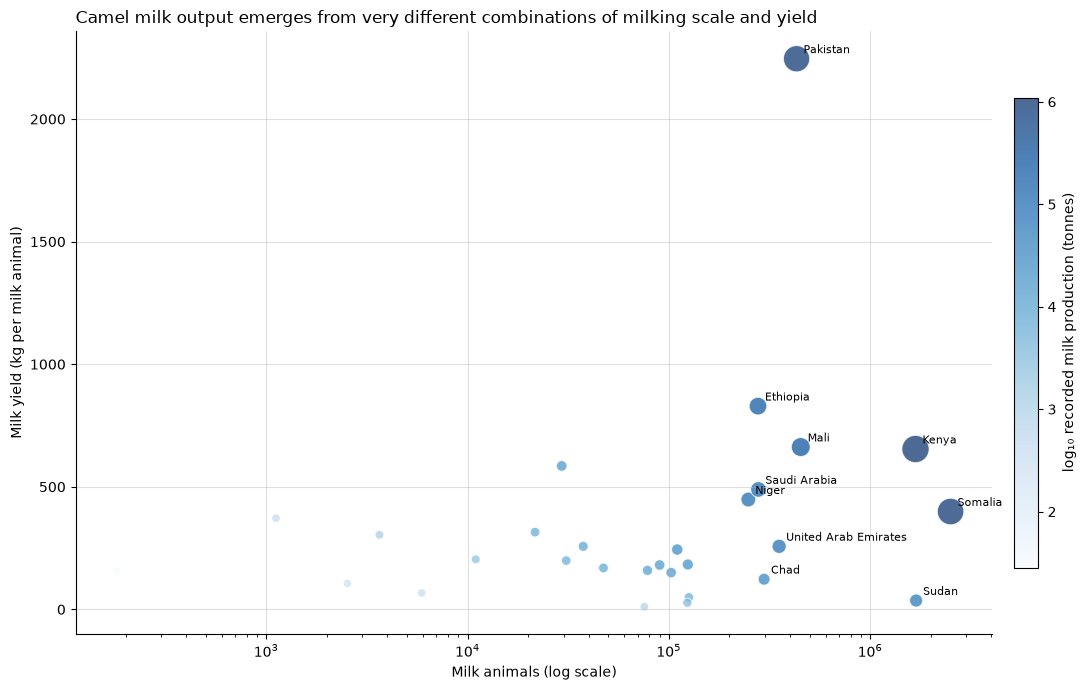

In [35]:
fig, ax = plt.subplots(figsize=(12, 7))

sizes = 35 + 350 * (milk24['Production'] / milk24['Production'].max()) ** .65

sc = ax.scatter(
    milk24['Milk Animals'],
    milk24['Yield/Carcass Weight'],
    s=sizes,
    c=np.log10(milk24['Production']),
    cmap='Blues',
    alpha=.72,
    edgecolor='white',
    linewidth=.75,
)

for _, r in milk24.nlargest(10, 'Production').iterrows():
    ax.annotate(
        r['Area'],
        (r['Milk Animals'], r['Yield/Carcass Weight']),
        xytext=(5, 4),
        textcoords='offset points',
        fontsize=8.2,
    )

ax.set(
    xscale='log',
    xlabel='Milk animals (log scale)',
    ylabel='Milk yield (kg per milk animal)',
)

ax.set_title(
    'Camel milk output emerges from very different combinations of milking scale and yield',
    loc='left',
)

ax.grid(alpha=.4)

fig.colorbar(
    sc,
    ax=ax,
    shrink=.78,
    pad=.02,
    label='log₁₀ recorded milk production (tonnes)',
)

fig.tight_layout()
plt.show()

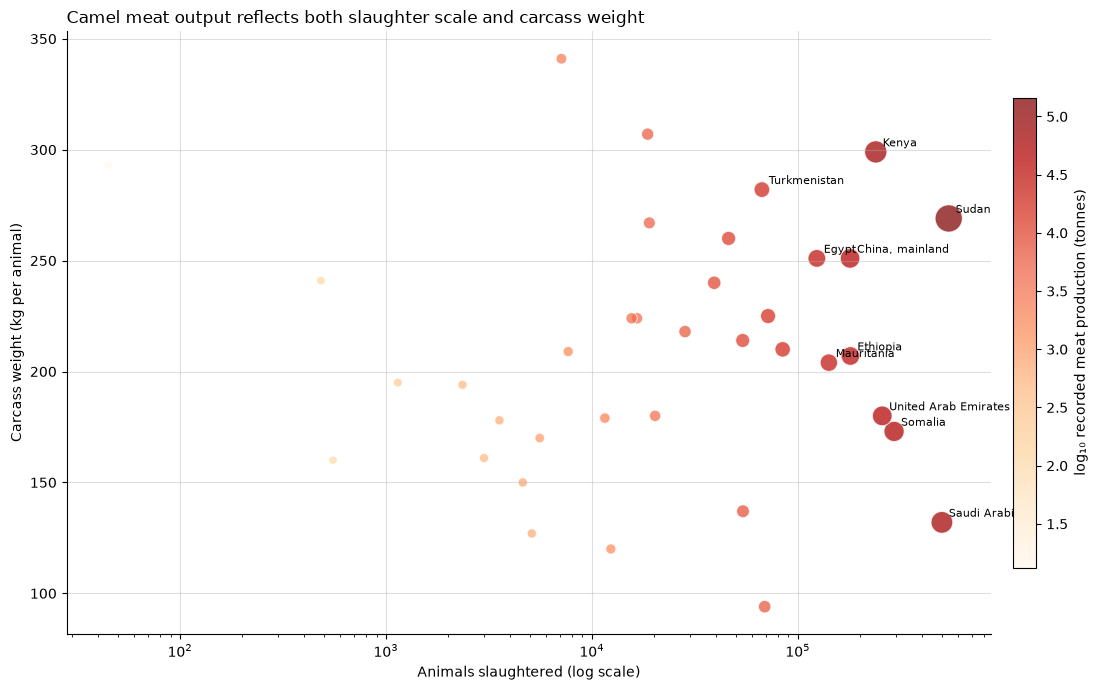

In [36]:
fig, ax = plt.subplots(figsize=(12, 7))

sizes = 35 + 350 * (meat24['Production'] / meat24['Production'].max()) ** .65

sc = ax.scatter(
    meat24['Producing Animals/Slaughtered'],
    meat24['Yield/Carcass Weight'],
    s=sizes,
    c=np.log10(meat24['Production']),
    cmap='OrRd',
    alpha=.72,
    edgecolor='white',
    linewidth=.75,
)

for _, r in meat24.nlargest(10, 'Production').iterrows():
    ax.annotate(
        r['Area'],
        (r['Producing Animals/Slaughtered'], r['Yield/Carcass Weight']),
        xytext=(5, 4),
        textcoords='offset points',
        fontsize=8.2,
    )

ax.set(
    xscale='log',
    xlabel='Animals slaughtered (log scale)',
    ylabel='Carcass weight (kg per animal)',
)

ax.set_title(
    'Camel meat output reflects both slaughter scale and carcass weight',
    loc='left',
)

ax.grid(alpha=.4)

fig.colorbar(
    sc,
    ax=ax,
    shrink=.78,
    pad=.02,
    label='log₁₀ recorded meat production (tonnes)',
)

fig.tight_layout()
plt.show()

In [37]:
prod_world = (
    camel_df
    .query(
        'Area == "World" and Element == "Production" '
        'and Item in ["Raw milk of camel", "Meat of camels, fresh or chilled"] '
        'and Year in [1961, 2000, 2024]'
    )
    .assign(
        product=lambda d: d['Item'].map({
            'Raw milk of camel': 'Milk',
            'Meat of camels, fresh or chilled': 'Meat',
        })
    )
    .pivot(index='product', columns='Year', values='Value')
    .rename(columns=lambda y: f'{y}_t')
    .assign(
        multiple_1961_2024=lambda d: d['2024_t'] / d['1961_t']
    )
    .reset_index()
)

display(
    prod_world.style.format({
        '1961_t': '{:,.0f}',
        '2000_t': '{:,.0f}',
        '2024_t': '{:,.0f}',
        'multiple_1961_2024': '{:.2f}×',
    })
)

Year,product,1961_t,2000_t,2024_t,multiple_1961_2024
0,Meat,"122,633","324,200","661,192",5.39×
1,Milk,"629,148","2,475,581","4,187,669",6.66×


Pakistan is the clearest milk system outlier: in 2024 it reports much higher yield per milk animal than the major African producers, allowing it to approach Somalia's milk output with a far smaller milking population. Kenya combines a very large milking population with moderate yield and is the largest recorded producer. In meat, Sudan's output is associated with both a large number slaughtered and relatively high carcass weight, whereas Saudi Arabia records a similarly large slaughter scale but lower carcass weight. These contrasts demonstrate why production tonnage alone is insufficient: the same output can arise from different production structures.

At World level, recorded camel milk output rises about __6.7x__ between 1961 and 2024 and camel meat about __5.4x__, both faster than the approximately __3.4x__ increase in stocks. Higher utilisation or productivity may have contributed to this increase, but changes in reporting and imputation also prevent a causal interpretation.

### RQ5 - How does data provenance qualify the apparent picture?

To begin answering the question, let's take a look at the share of represented camel numbers associated with each provenance flag:

In [38]:
flag_share = (
    reporting_entity_stocks
    .query('Flag in ["A", "E", "I", "X"]')
    .dropna(subset=['Value'])
    .groupby(['Year', 'Flag'])['Value'].sum()
    .unstack(fill_value=0)
    .reindex(columns=['A', 'E', 'I', 'X'], fill_value=0)
    .pipe(lambda d: d.div(d.sum(axis=1), axis=0).mul(100))
)

display(flag_share.loc[[1961, 1980, 2000, 2010, 2020, 2024]].round(1))

Flag,A,E,I,X
Year,,,,
1961,63.0,37.0,0.0,0.0
1980,76.1,23.9,0.0,0.0
2000,83.0,17.0,0.0,0.0
2010,56.3,41.6,0.0,2.0
2020,68.5,0.0,30.3,1.1
2024,25.2,6.3,68.6,0.0


The historical composition changes sharply. Official figures represented approximately 83.0% of the stock-weighted total in 2000, compared with only 25.2% in 2024, while the imputed share rises from effectively zero in earlier benchmark years to 30.3% in 2020 and 68.6% in 2024.

In [39]:
stock2024 = (
    country_stocks
    .query('Year == 2024')
    .dropna(subset=['Value'])
    [['Area', 'ISO3', 'Value', 'Flag']]
    .sort_values('Value', ascending=False)
    .assign(
        world_share_pct=lambda d: d['Value'].div(world_stock.loc[2024]).mul(100)
    )
    .reset_index(drop=True)
)

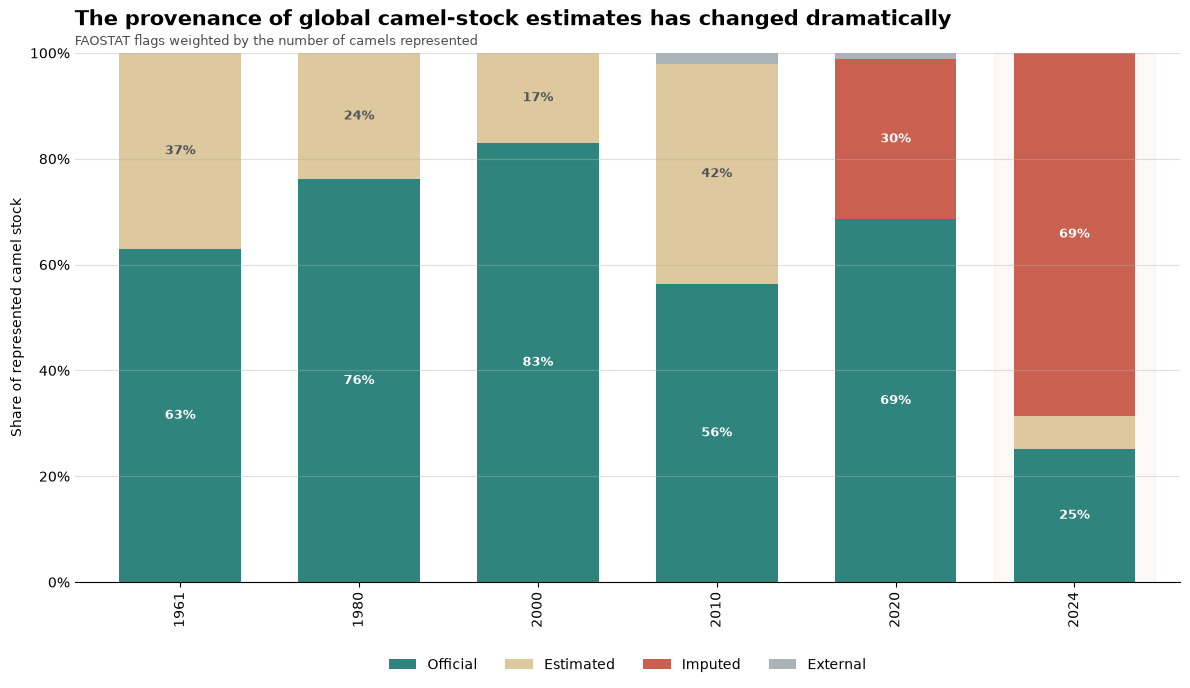

In [40]:
years = [1961, 1980, 2000, 2010, 2020, 2024]
flags = ['A', 'E', 'I', 'X']

FLAG_COLORS = {
    'A': '#2f857d',
    'E': '#dec89d',
    'I': '#ca6150',
    'X': '#aab3b7',
}
FLAG_LABELS = {
    'A': 'Official',
    'E': 'Estimated',
    'I': 'Imputed',
    'X': 'External',
}

d = flag_share.loc[years, flags]

fig, ax = plt.subplots(figsize=(12, 7))

d.rename(columns=FLAG_LABELS).plot.bar(
    stacked=True,
    ax=ax,
    width=.68,
    color=[FLAG_COLORS[f] for f in flags],
)

# Label meaningful segments.
for flag, container in zip(flags, ax.containers):
    values = d[flag]
    ax.bar_label(
        container,
        labels=[f'{v:.0f}%' if v >= 8 else '' for v in values],
        label_type='center',
        fontsize=9,
        fontweight='bold',
        color='white' if flag in ['A', 'I'] else '#4f5558',
    )

ax.axvspan(4.55, 5.45, color='#ca6150', alpha=.045, zorder=0)

ax.set(
    ylim=(0, 100),
    xlabel='',
    ylabel='Share of represented camel stock',
)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())

ax.set_title(
    'The provenance of global camel-stock estimates has changed dramatically',
    loc='left', fontsize=15, fontweight='bold', pad=20,
)
ax.text(
    0, 1.015,
    'FAOSTAT flags weighted by the number of camels represented',
    transform=ax.transAxes, fontsize=9.5, alpha=.7,
)

ax.legend(ncol=4, frameon=False, loc='upper center', bbox_to_anchor=(.5, -.12))
ax.grid(axis='y', alpha=.4)
ax.spines[['top', 'right', 'left']].set_visible(False)
ax.tick_params(axis='y', length=0)

fig.tight_layout()
plt.show()

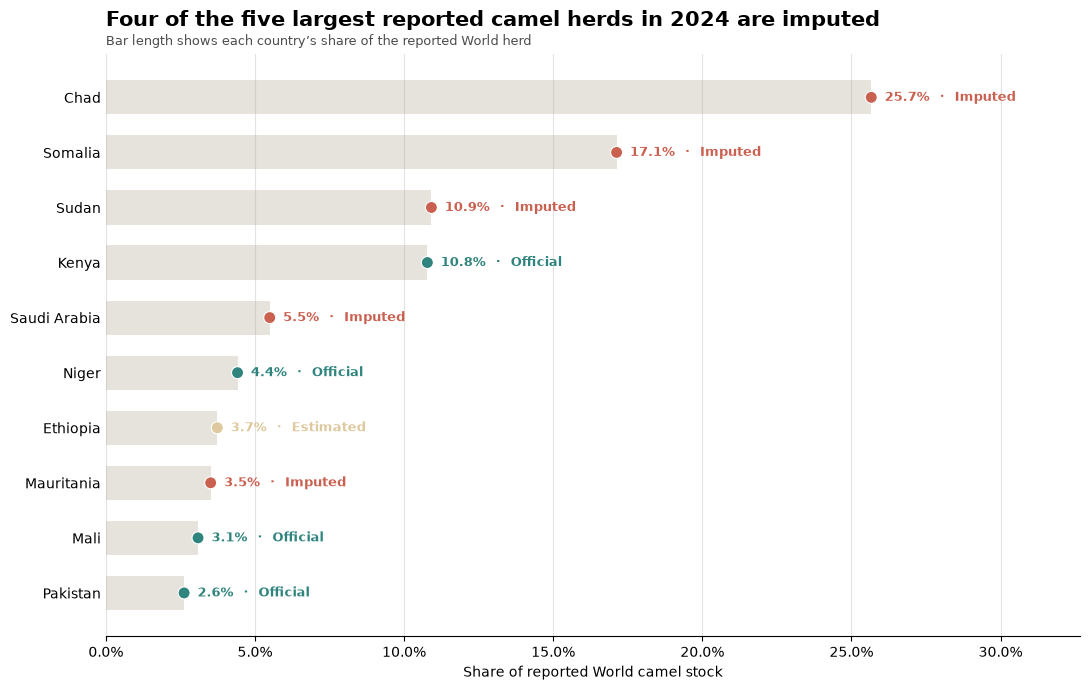

In [41]:
top = stock2024.head(10).sort_values('world_share_pct')
colors = top['Flag'].map(FLAG_COLORS)

fig, ax = plt.subplots(figsize=(11, 7))

ax.barh(top['Area'], top['world_share_pct'], color='#e6e2dc', height=.62)
ax.scatter(
    top['world_share_pct'],
    range(len(top)),
    s=75,
    c=colors,
    edgecolor='white',
    linewidth=.8,
    zorder=3,
)

for y, (share, flag) in enumerate(zip(top['world_share_pct'], top['Flag'])):
    ax.text(
        share + .45,
        y,
        f'{share:.1f}%  ·  {FLAG_LABELS[flag]}',
        va='center',
        fontsize=9,
        fontweight='bold',
        color=FLAG_COLORS[flag],
    )

ax.set(
    xlim=(0, top['world_share_pct'].max() + 7),
    xlabel='Share of reported World camel stock',
    ylabel='',
)

ax.set_title(
    'Four of the five largest reported camel herds in 2024 are imputed',
    loc='left', fontsize=15, fontweight='bold', pad=20,
)

ax.text(
    0, 1.015,
    'Bar length shows each country’s share of the reported World herd',
    transform=ax.transAxes, fontsize=9.5, alpha=.7,
)

ax.xaxis.set_major_formatter(mtick.PercentFormatter())
ax.grid(axis='x', alpha=.35)
ax.tick_params(axis='y', length=0)
ax.spines[['top', 'right', 'left']].set_visible(False)

fig.tight_layout()
plt.show()

The fingerprint chart further shows that this imputation shift is concentrated among consequential national series: four of the five largest reported herds in 2024 carry an imputed flag. Having noted that - it is important to distinguish that an imputed observation should not be equated with an incorrect observation. Where official reporting is unavailable, imputation may be the best available estimate. The flag affects how confidently the value should be interpreted - it does not make the value unusable.

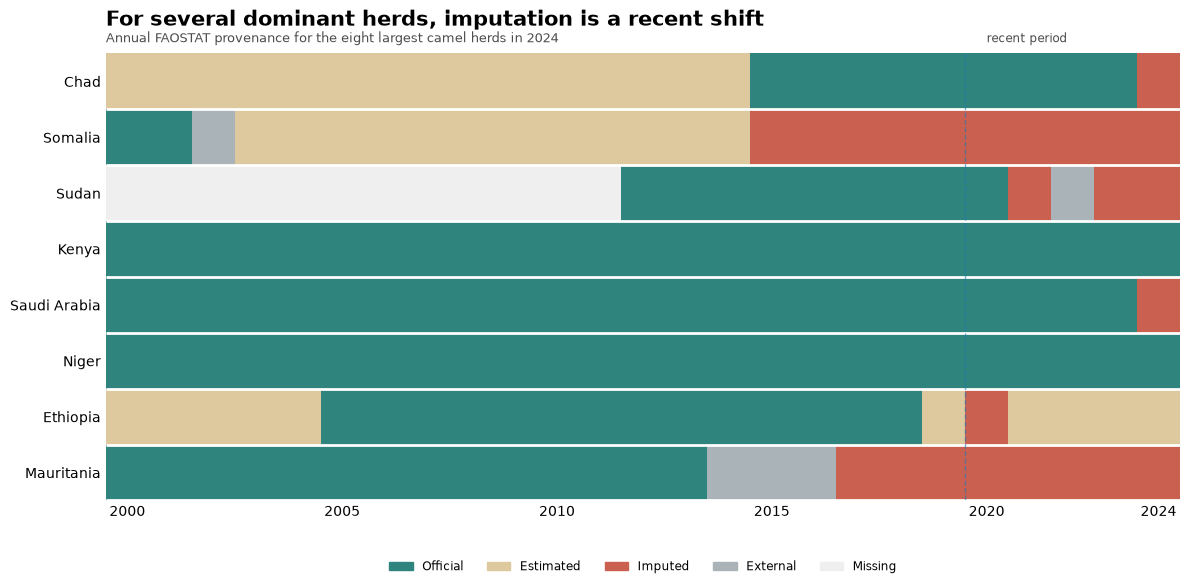

In [42]:
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch

areas = stock2024.head(8)['Area']

flags = (
    country_stocks
    .query('Area in @areas and 2000 <= Year <= 2024')
    .pivot(index='Area', columns='Year', values='Flag')
    .reindex(areas)
)

codes = {f: i for i, f in enumerate(['A', 'E', 'I', 'X'])}
colors = [FLAG_COLORS[f] for f in codes] + ['#efefef']
z = flags.replace(codes).fillna(4).astype(float)

fig, ax = plt.subplots(figsize=(12, 6))

ax.imshow(
    z,
    aspect='auto',
    cmap=ListedColormap(colors),
    vmin=-.5,
    vmax=4.5,
    interpolation='nearest',
)

# Country separators
ax.hlines(
    np.arange(.5, len(flags)),
    -.5, len(flags.columns) - .5,
    color='white', linewidth=2,
)

tick_years = [2000, 2005, 2010, 2015, 2020, 2024]
ax.set_xticks(flags.columns.get_indexer(tick_years), tick_years)
ax.set_yticks(range(len(flags)), flags.index)

x2020 = flags.columns.get_loc(2020)
ax.axvline(x2020 - .5, linestyle='--', linewidth=1, alpha=.6)
ax.text(x2020, -.7, 'recent period', fontsize=8.5, alpha=.7)

ax.set_title(
    'For several dominant herds, imputation is a recent shift',
    loc='left', fontsize=15, fontweight='bold', pad=20,
)
ax.text(
    0, 1.025,
    'Annual FAOSTAT provenance for the eight largest camel herds in 2024',
    transform=ax.transAxes, fontsize=9.5, alpha=.7,
)

legend = [
    Patch(color=FLAG_COLORS[f], label=FLAG_LABELS[f])
    for f in codes
] + [Patch(color='#efefef', label='Missing')]

ax.legend(
    handles=legend,
    ncol=5,
    frameon=False,
    loc='upper center',
    bbox_to_anchor=(.5, -.11),
    fontsize=8.5,
)

ax.tick_params(length=0)
ax.spines[:].set_visible(False)

fig.tight_layout()
plt.show()

The most important caution in the project is visible here. In 2024, only about __one quarter__ of represented country-level camel stock is attached to an `A` (official) flag, while roughly __68.6% is imputed__. The categorical fingerprint shows that this is not evenly distributed noise: several of the largest contemporary herds rely heavily on imputation for recent years. Consequently, visually precise country rankings should not be interpreted as if every national estimate had identical evidential status.

This does not make FAOSTAT unusable - to the contrary, the flags add value because they allow the visualisation to communicate provenance rather than hide it. The appropriate conclusion is conditional: the broad growth and concentration patterns are substantial, but the apparent precision of individual recent-country values is weaker than an unflagged chart would imply. The long-run flag-share calculation uses both present-day countries and the non-overlapping historical reporting entities identified during preprocessing, so the early-period denominator remains consistent with FAOSTAT's World total.

## Conclusions

The visual investigation reveals a clear long-run expansion and geographical concentration of reported camel husbandry. FAOSTAT's World stock increases from approximately __12.9 million animals in 1961 to 44.3 million in 2024__, with about __71.5% of the net increase occurring after 2000__. At the same time, Africa's share rises from roughly __66.6% to 83.5%__, and the post-2000 increase is concentrated in a relatively small group of countries rather than distributed evenly across the camel-keeping world.

Herd size is strongly associated with recorded output but does not determine it. On logarithmic scales it explains roughly two-thirds of the cross-country variation in 2024 milk and meat production. The decomposition into animals milked/slaughtered and yield/carcass weight shows why: countries can reach similar output through very different combinations of production scale and recorded productivity. World milk and meat output have also risen faster than camel stocks themselves.

The main limitation lies in the underlying evidence rather than the visualisations themselves. Historical political entities complicate national time-series comparison, stock and product reference periods are not perfectly aligned, and __68.6% of represented 2024 camel stock is flagged as imputed__. The figures support the broad findings on growth, concentration and production structure, but individual national estimates cannot always be interpreted with the same degree of precision. Including provenance is essential to interpreting the recent country-level results.

Overall, four patterns stand out: camel numbers have increased substantially, the global herd has become more geographically concentrated, production structures differ greatly between countries, and many of the largest recent estimates rely on a different evidence base from earlier observations.

Future work could validate a small number of high-impact national series against livestock censuses or other primary sources, particularly where FAOSTAT observations change from official to imputed status.

## References

FAO. (2025). *FAOSTAT: Crops and Livestock Products (QCL)* [Data set]. Food and Agriculture Organization of the United Nations. CC BY 4.0. https://data.fao.org/catalog/iso/d24a448b-3b62-4c09-8c1d-4a39bb599876

FAO. (n.d.). *FAOSTAT Crops and Livestock Products: methodology - agricultural production, livestock*. Food and Agriculture Organization of the United Nations. https://files-faostat.fao.org/production/QCL/QCL_methodology_e.pdf

Faye, B. (2020). How many large camelids in the world? A synthetic analysis of the world camel demographic changes. *Pastoralism, 10*, 25. https://doi.org/10.1186/s13570-020-00176-z

Natural Earth. (n.d.). *Natural Earth vector map data: Admin 0 countries*. https://www.naturalearthdata.com/

## Appendices

## Word Count

The following code will count the number of words in Markdown cells. Code cells are not included.

- `Main word count` is the number of words in the main body of the text, *excluding* references or appendices.
- `References and appendices word count` is the number of words in any references or appendices.

Only `Main word count` relates to the assignment word limit. There is no limit to the number of words that can be included in references or appendices. Please note that appendices should only be used to provide context or supporting information. *No marks will be directly awarded for material submitted in appendices*.

Important:

- Please do not modify the word count code!
- To exclude references from your word count **you must** have a cell that starts with the text `## References`. Everything below this cell will not count towards the main word count.
- If you are submitting additional material as appendices **you must** have a cell that starts with the text `## Appendices`. Everything below this cell will not count towards the main word count. If you do not have any appendices you can delete the `## Appendices` cell.
- Code comments should only be used to explain details of the implementation, not for discussing your findings. All analysis commentary **must** be written in Markdown cells. *No marks will be awarded for analysis discussion submitted as comments in code cells*.

In [43]:
%%js

// Run this cell to update your word count.

function wordcount() {
    let wordCount = 0
    let extraCount = 0
    let mainBody = true

    let cells = Jupyter.notebook.get_cells()
    cells.forEach((cell) => {
        if (cell.cell_type == 'markdown') {
            let text = cell.get_text()
            // Stop counting as main body when get to References or Appendices.
            if (text.startsWith('## References') ||
                text.startsWith('## Appendices')) {
                mainBody = false
            }
            if (text.startsWith('## Word Count')) {
                text = ''
            }
            if (text) {
                let words = text.toLowerCase().match(/\b[a-z\d]+\b/g)
                if (words) {
                    let cellCount = words.length
                    if (mainBody) {
                        wordCount += cellCount
                    } else {
                        extraCount += cellCount
                    }
                }
            }
        }
    })
    return [wordCount, extraCount]
}

let wc = wordcount()
element.append(`Main word count: ${wc[0]} (References and appendices word count: ${wc[1]})`)

<IPython.core.display.Javascript object>